# AMBR feature extraction with 6 variables

Standalone notebook derived from the feature-selection workflow, updated to include **Off-gas CO2%** as the sixth variable.

Variable order used throughout:
1. Glucose
2. DO
3. pH
4. Biomass
5. Volume
6. Off-gas CO2%

The key indexing rule is `i * n_vars + var_idx`, where `n_vars = 6`. Keeping `n_vars = len(var_names)` avoids hard-coding the number.

In [32]:
# Imports
import os
import re
import numpy as np
import pandas as pd

# Paths: adjust only if your folder structure differs
AMBR_DIR = os.path.join(os.getcwd(), "ambr")
GLUCOSE_RUN1 = os.path.join(os.getcwd(), "Lorena_dataset", "Glucose_files_310326", "OfflineMetabolites_AMBR1.csv")
GLUCOSE_RUN2 = os.path.join(os.getcwd(), "Lorena_dataset", "Glucose_files_310326", "OfflineMetabolites_AMBR2.xlsx")

ALL_VAR_NAMES = ["Glucose", "DO", "pH", "Biomass", "Volume"]
print(f"Available variables: {ALL_VAR_NAMES}")


Available variables: ['Glucose', 'DO', 'pH', 'Biomass', 'Volume']


## 1. Load and merge AMBR online data

Only the online variables needed for this feature set are retained. `Off-gas CO2%` is kept explicitly.

In [33]:
csv_files = sorted([f for f in os.listdir(AMBR_DIR) if f.lower().endswith(".csv")])

frames = []
for filename in csv_files:
    path = os.path.join(AMBR_DIR, filename)
    data = pd.read_csv(path)

    data.columns = data.columns.str.strip().str.replace("\ufeff", "", regex=False)
    data = data.loc[:, ~data.columns.duplicated()]

    if "Time" not in data.columns:
        raise ValueError(f"No Time column in {filename}")

    # Infer run tag from filename, e.g. run1 / run2
    match = re.search(r"run(\d+)", filename, flags=re.IGNORECASE)
    if match is None:
        raise ValueError(f"Could not infer run tag from filename: {filename}")
    run_tag = f"run{match.group(1)}"

    keep = [
        c for c in data.columns
        if c == "Time"
        or "Optical density" in c
        or re.search(r"\bDO\b", c)
        or re.search(r"\bpH\b", c)
        or "Volume" in c
        or "Off-gas CO2%" in c
    ]
    data = data[keep].copy()

    # Append run tag to every measurement column
    data = data.rename(columns={c: f"{c} {run_tag}" for c in data.columns if c != "Time"})
    data = data.sort_values("Time").reset_index(drop=True)
    frames.append(data)

if not frames:
    raise ValueError(f"No CSV files found in {AMBR_DIR}")

df_merged = frames[0]
for frame in frames[1:]:
    df_merged = pd.merge(df_merged, frame, on="Time", how="outer")

df_merged = df_merged.sort_values("Time").reset_index(drop=True)
print(df_merged.shape)
df_merged.head()

(744, 146)


,Time,Bioreactor 13 - DO run1,Bioreactor 13 - Off-gas CO2% run1,Bioreactor 13 - Optical density run1,Bioreactor 13 - pH run1,Bioreactor 13 - Volume run1,Bioreactor 14 - DO run1,Bioreactor 14 - Off-gas CO2% run1,Bioreactor 14 - Optical density run1,Bioreactor 14 - pH run1,...,Bioreactor 9 - DO run2,Bioreactor 9 - Off-gas CO2% run2,Bioreactor 9 - Optical density run2,Bioreactor 9 - pH run2,Bioreactor 9 - Volume run2,Bioreactor 10 - DO run2,Bioreactor 10 - Off-gas CO2% run2,Bioreactor 10 - Optical density run2,Bioreactor 10 - pH run2,Bioreactor 10 - Volume run2
0,0.000000,99.872020,0.025539,1.160858,8.464141,200.140103,99.946632,0.034920,1.193741,7.980853,...,99.691106,0.006080,NaN,6.325682,205.710423,100.101021,0.002000,NaN,6.271189,205.890175
1,0.083333,99.416954,0.031698,1.413499,8.485270,209.922825,99.294889,0.046732,1.557839,7.981481,...,96.059226,0.042747,1.332548,6.331600,210.556219,96.517083,0.033767,0.940273,6.279504,210.738731
2,0.166667,100.200861,0.032617,1.228155,8.511576,209.921492,100.279096,0.052147,1.342887,8.002334,...,94.534381,0.047172,0.996746,6.331346,210.550687,95.032374,0.034439,0.935910,6.281289,210.733208
3,0.250000,100.084997,0.033688,1.164406,8.515495,209.915948,100.049807,0.054623,1.427997,8.008087,...,93.792859,0.035703,1.093541,6.330874,210.545161,94.493405,0.023761,0.910986,6.282000,210.727684
4,0.333333,100.020934,0.033354,1.269137,8.516580,209.056513,100.005836,0.054421,1.421500,8.008910,...,93.196854,0.031388,0.989038,6.329718,210.539635,93.821768,0.019598,0.915177,6.281601,210.722161


## 2. Convert optical density to biomass

This keeps the same AMBR conversion used in your original notebook: `Biomass = OD * 0.4267`.

In [34]:
for col in list(df_merged.columns):
    if "Optical density" not in col:
        continue

    biomass_col = col.replace("Optical density", "Biomass")
    df_merged[biomass_col] = df_merged[col] * 0.4267

df_merged = df_merged.drop(columns=[c for c in df_merged.columns if "Optical density" in c])

# Quick check that CO2 is present
co2_cols = [c for c in df_merged.columns if "Off-gas CO2%" in c]
print(f"Found {len(co2_cols)} Off-gas CO2% columns")
print(co2_cols[:10])

Found 29 Off-gas CO2% columns
['Bioreactor 13 - Off-gas CO2% run1', 'Bioreactor 14 - Off-gas CO2% run1', 'Bioreactor 15 - Off-gas CO2% run1', 'Bioreactor 16 - Off-gas CO2% run1', 'Bioreactor 17 - Off-gas CO2% run1', 'Bioreactor 18 - Off-gas CO2% run1', 'Bioreactor 19 - Off-gas CO2% run1', 'Bioreactor 21 - Off-gas CO2% run1', 'Bioreactor 22 - Off-gas CO2% run1', 'Bioreactor 23 - Off-gas CO2% run1']


## 3. Load offline glucose measurements

In [35]:
glucose1 = pd.read_csv(GLUCOSE_RUN1, delimiter=";")
glucose2 = pd.read_excel(GLUCOSE_RUN2)

glc1 = glucose1[["Reactor", "Time", "Glucose"]].copy()
glc2 = glucose2[["Reactor", "Time", "Glucose Vanquish"]].copy()

# Identify reactor/run combinations from the online columns
reactor_runs = []
for col in df_merged.columns:
    if col == "Time":
        continue
    m = re.match(r"^(Bioreactor \d+) - .* (run\d+)$", col)
    if m:
        pair = (m.group(1), m.group(2))
        if pair not in reactor_runs:
            reactor_runs.append(pair)

reactor_runs = sorted(reactor_runs, key=lambda x: (int(x[0].split()[-1]), x[1]))
print(f"Detected {len(reactor_runs)} reactor/run combinations")
print(reactor_runs[:10])

Detected 29 reactor/run combinations
[('Bioreactor 5', 'run2'), ('Bioreactor 6', 'run2'), ('Bioreactor 7', 'run2'), ('Bioreactor 8', 'run2'), ('Bioreactor 9', 'run2'), ('Bioreactor 10', 'run2'), ('Bioreactor 11', 'run2'), ('Bioreactor 12', 'run2'), ('Bioreactor 13', 'run1'), ('Bioreactor 13', 'run2')]


In [36]:
glucose_df = pd.DataFrame({"Time": sorted(set(glc1["Time"].dropna()) | set(glc2["Time"].dropna()))})

for bio_name, run_tag in reactor_runs:
    out_name = f"{bio_name} {run_tag}"

    if run_tag == "run1":
        bior = glc1.loc[glc1["Reactor"] == bio_name, ["Time", "Glucose"]].copy()
        bior = bior.rename(columns={"Glucose": out_name})
    elif run_tag == "run2":
        bior = glc2.loc[glc2["Reactor"] == bio_name, ["Time", "Glucose Vanquish"]].copy()
        bior = bior.rename(columns={"Glucose Vanquish": out_name})
    else:
        continue

    glucose_df = pd.merge(glucose_df, bior, on="Time", how="outer")

glucose_df = glucose_df.sort_values("Time").reset_index(drop=True)
glucose_df.head()

,Time,Bioreactor 5 run2,Bioreactor 6 run2,Bioreactor 7 run2,Bioreactor 8 run2,Bioreactor 9 run2,Bioreactor 10 run2,Bioreactor 11 run2,Bioreactor 12 run2,Bioreactor 13 run1,...,Bioreactor 18 run2,Bioreactor 19 run1,Bioreactor 19 run2,Bioreactor 20 run2,Bioreactor 21 run1,Bioreactor 21 run2,Bioreactor 22 run1,Bioreactor 22 run2,Bioreactor 23 run1,Bioreactor 24 run1
0,0.333333,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10.137579,...,NaN,9.962565,NaN,NaN,10.348804,NaN,10.156743,NaN,10.167679,10.356501
1,0.583333,10.19,10.26,10.05,10.27,20.56,20.25,4.020000,4.16,NaN,...,10.12,NaN,10.22,10.28,NaN,10.400000,NaN,10.440000,NaN,NaN
2,4.333333,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,4.583333,10.62,10.04,9.37,9.81,18.35,19.55,4.683215,3.79,NaN,...,9.76,NaN,9.19,9.26,NaN,9.533869,NaN,9.538577,NaN,NaN
4,4.666667,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


# Comparison of 4-, 5-, and 6-variable representations

This notebook compares three representations of the same VTT/AMBR cultivations using an identical analysis pipeline:

- **4 variables:** Glucose, DO, pH, Biomass
- **5 variables:** Glucose, DO, pH, Biomass, Volume
- **6 variables:** Glucose, DO, pH, Biomass, Volume, Off-gas CO2%

For each representation, the notebook extracts the same six trajectory descriptors, removes highly correlated features, standardizes the retained features, performs PCA, evaluates K-means clustering across several values of `k`, and estimates cluster stability. The final table is intended to support selection of the representation rather than choosing from the visual appearance of a PCA plot alone.


In [37]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, adjusted_rand_score
import matplotlib.pyplot as plt

VARIABLE_SETS = {
    "4 variables": ["Glucose", "DO", "pH", "Biomass"],
    "5 variables": ["Glucose", "DO", "pH", "Biomass", "Volume"],
    "6 variables": ["Glucose", "DO", "pH", "Biomass", "Volume", "Off-gas CO2%"],
}

METRICS = ["AUC", "Slope", "Max", "Min", "First", "Last"]
CORR_THRESHOLD = 0.85
TARGET_CUMULATIVE_VARIANCE = 0.75
K_VALUES = range(2, 13)
RANDOM_STATE = 42
N_STABILITY_REPEATS = 100
SUBSAMPLE_FRACTION = 0.80


## 1. Build a common six-variable trajectory store

All three analyses must be based on the **same cultivations**. We therefore first retain only reactor/run combinations for which glucose and all five online variables are available. This avoids an apparent improvement caused simply by comparing different sets of experiments.


In [38]:
trajectory_store = {}

def online_column(bio_name, variable, run_tag):
    return f"{bio_name} - {variable} {run_tag}"

for bio_name, run_tag in reactor_runs:
    glucose_col = f"{bio_name} {run_tag}"
    required_online = {
        variable: online_column(bio_name, variable, run_tag)
        for variable in ALL_VAR_NAMES[1:]
    }

    if glucose_col not in glucose_df.columns:
        continue
    if any(col not in df_merged.columns for col in required_online.values()):
        continue

    m = re.match(r"Bioreactor (\d+) run(\d+)", f"{bio_name} {run_tag}")
    reactor_id = f"B{m.group(1)}R{m.group(2)}" if m else f"{bio_name} {run_tag}"
    trajectory_store[reactor_id] = {}

    s = glucose_df[glucose_col].dropna()
    t = glucose_df.loc[s.index, "Time"]
    trajectory_store[reactor_id]["Glucose"] = (
        t.to_numpy(dtype=float), s.to_numpy(dtype=float)
    )

    for variable, col in required_online.items():
        s = df_merged[col].dropna()
        t = df_merged.loc[s.index, "Time"]
        trajectory_store[reactor_id][variable] = (
            t.to_numpy(dtype=float), s.to_numpy(dtype=float)
        )

print(f"Cultivations available for all 6 variables: {len(trajectory_store)}")
print(list(trajectory_store)[:10])


Cultivations available for all 6 variables: 29
['B5R2', 'B6R2', 'B7R2', 'B8R2', 'B9R2', 'B10R2', 'B11R2', 'B12R2', 'B13R1', 'B13R2']


In [39]:
bior_test = len(list(trajectory_store))-1
list(trajectory_store)[bior_test]

'B24R1'

In [40]:
bior

,Time,Bioreactor 24 run1
10,0.333333,10.356501
21,4.333333,NaN
32,6.333333,NaN
43,8.333333,7.532651
54,10.333333,NaN
65,11.916667,4.860755
76,12.333333,4.267173
87,14.333333,2.728781
95,14.833333,2.510435
109,16.333333,1.418754


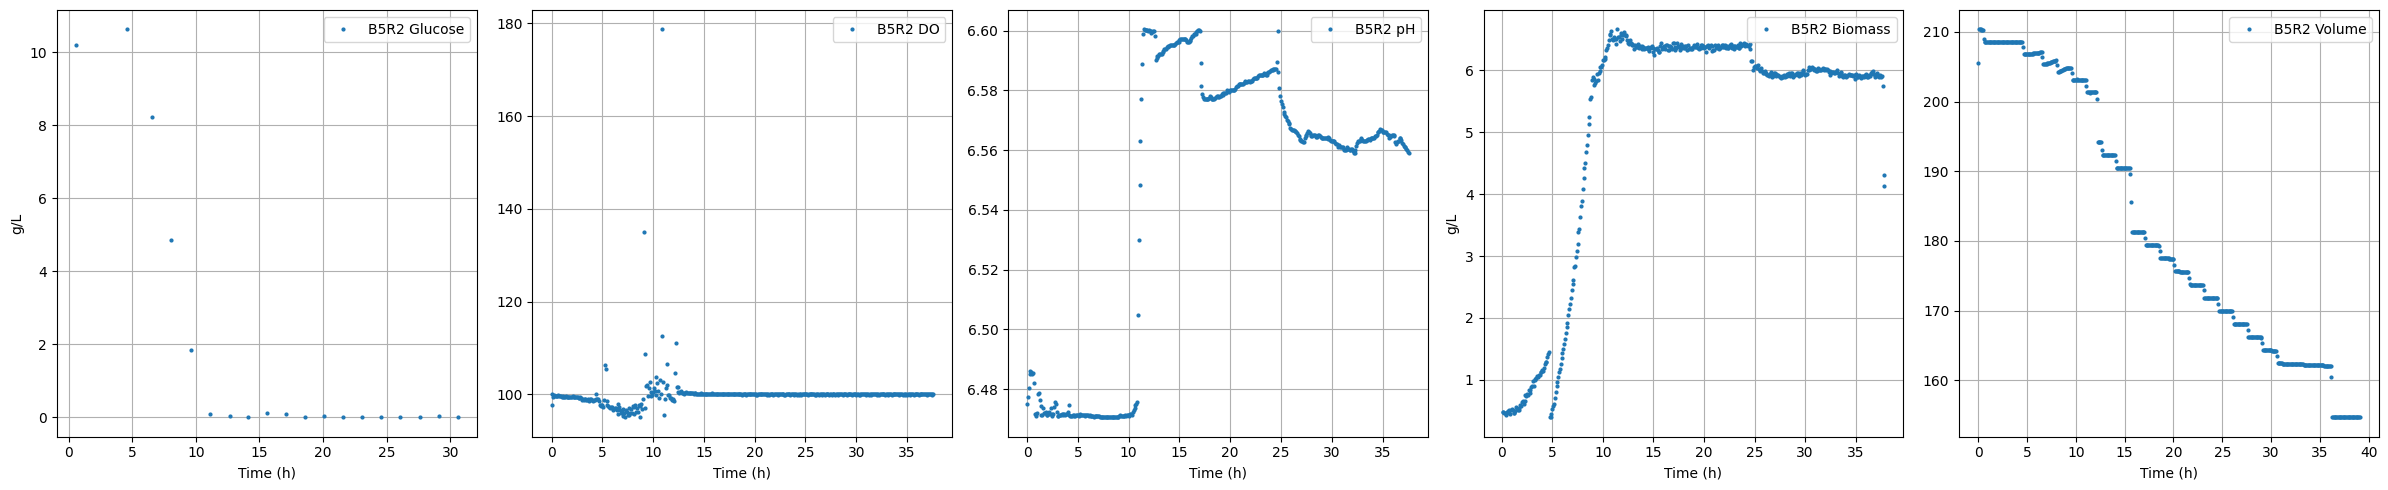

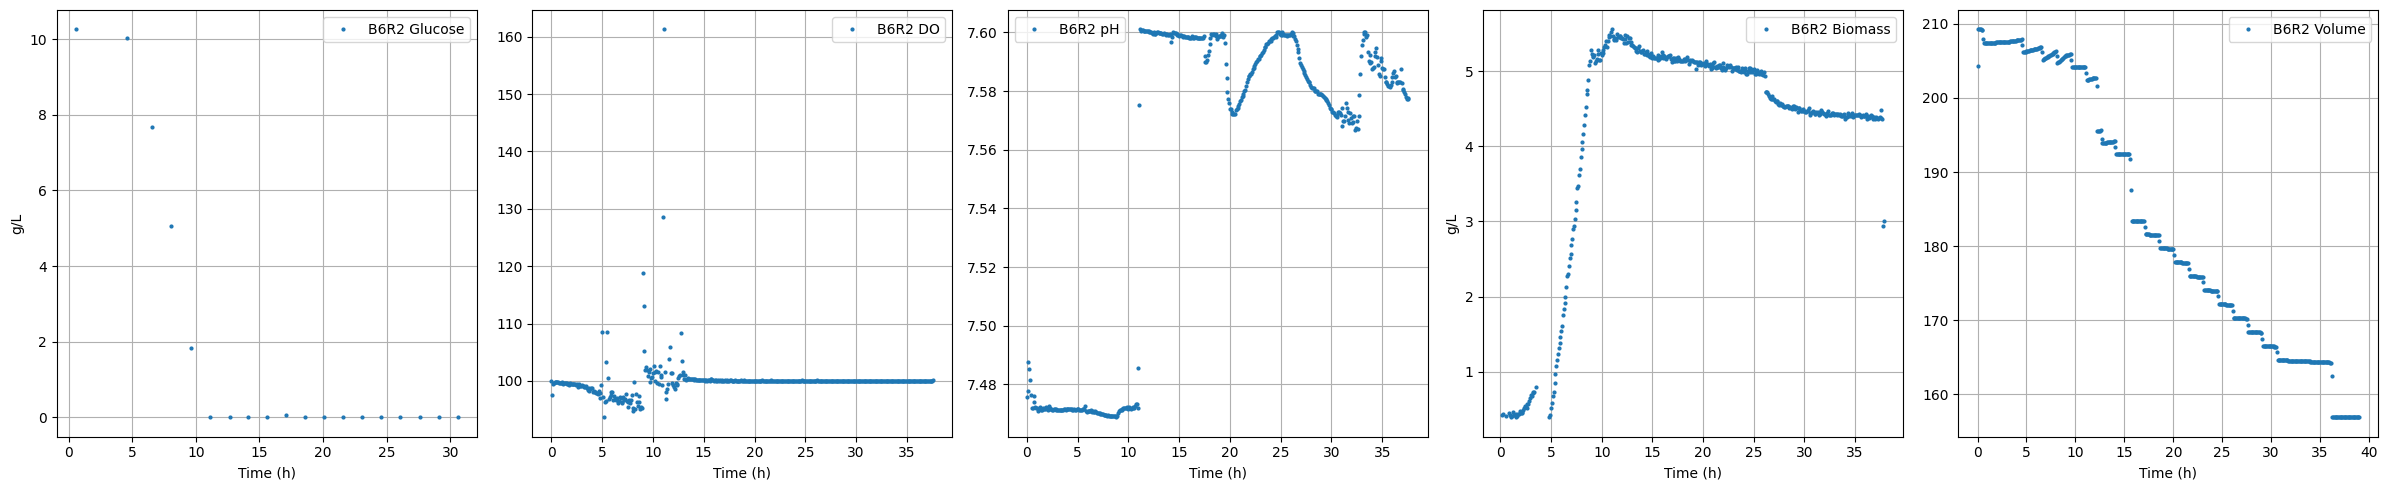

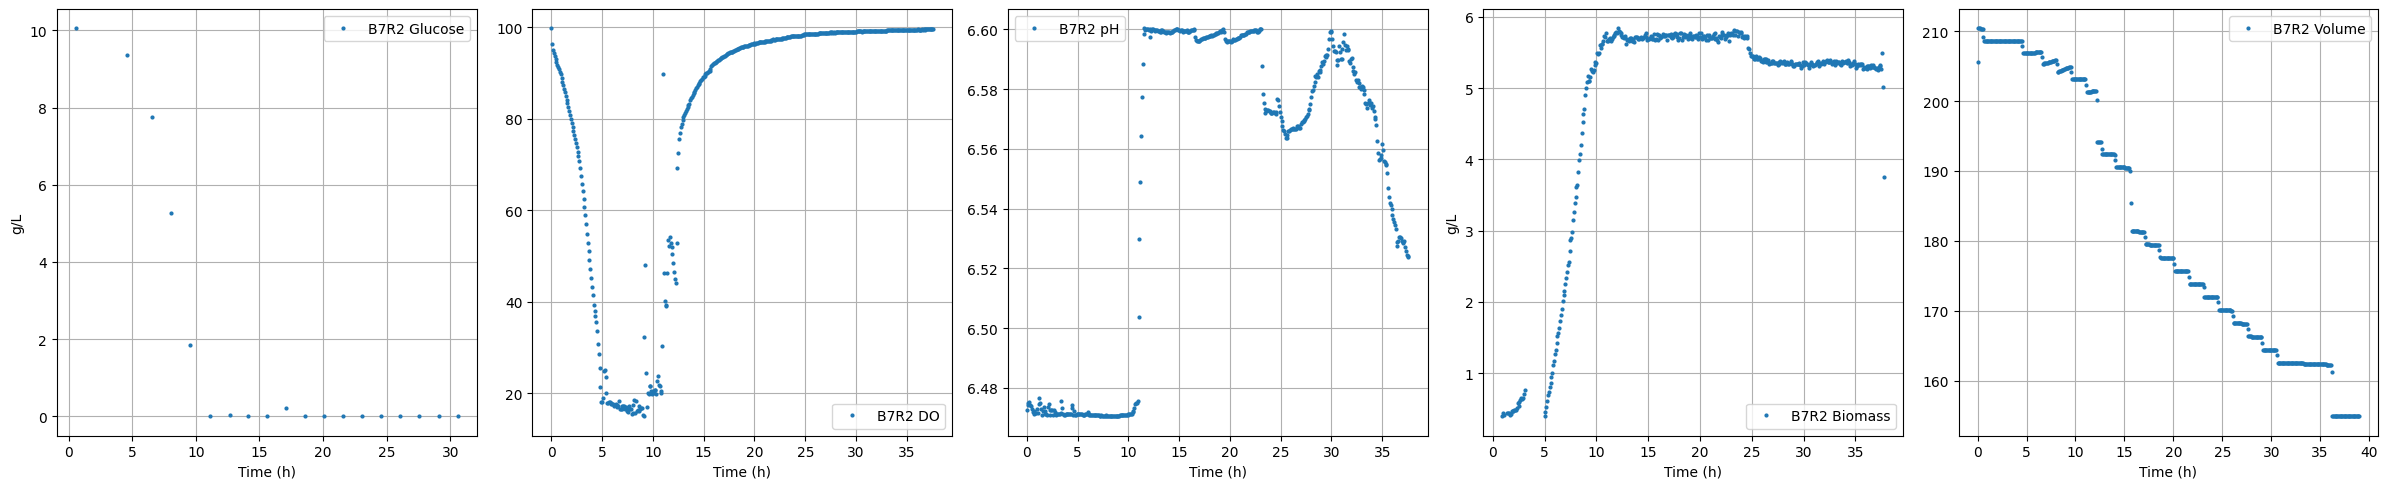

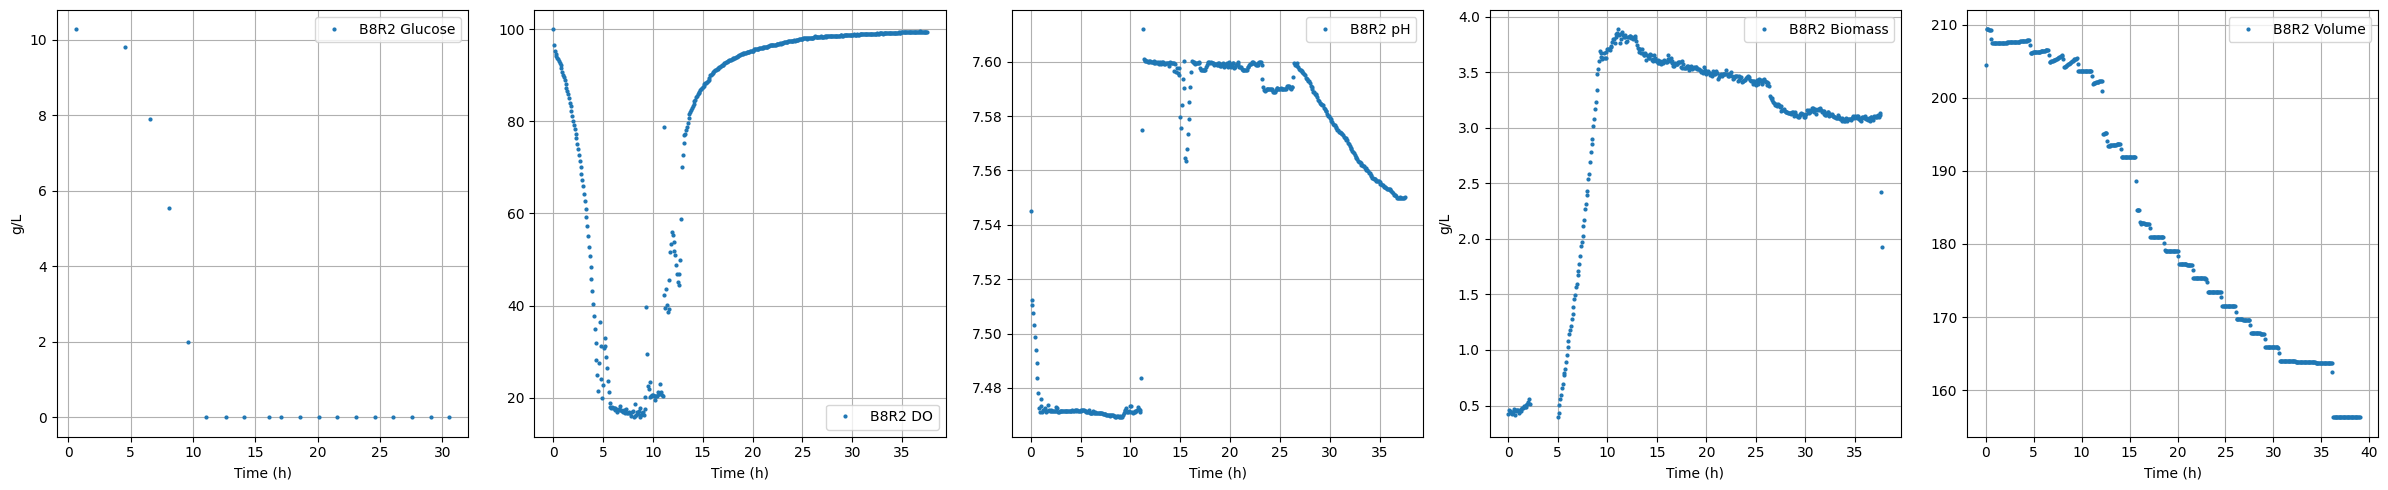

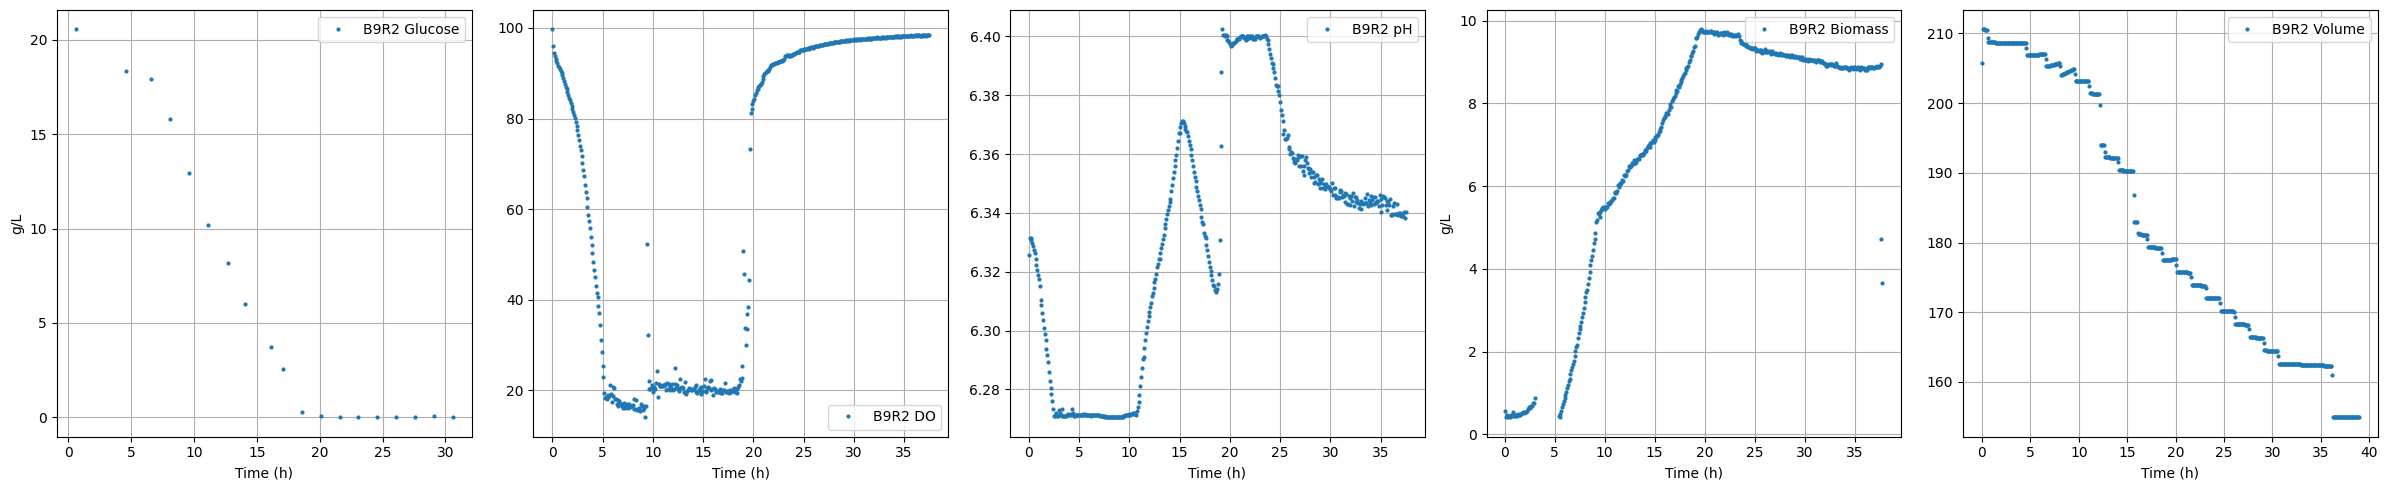

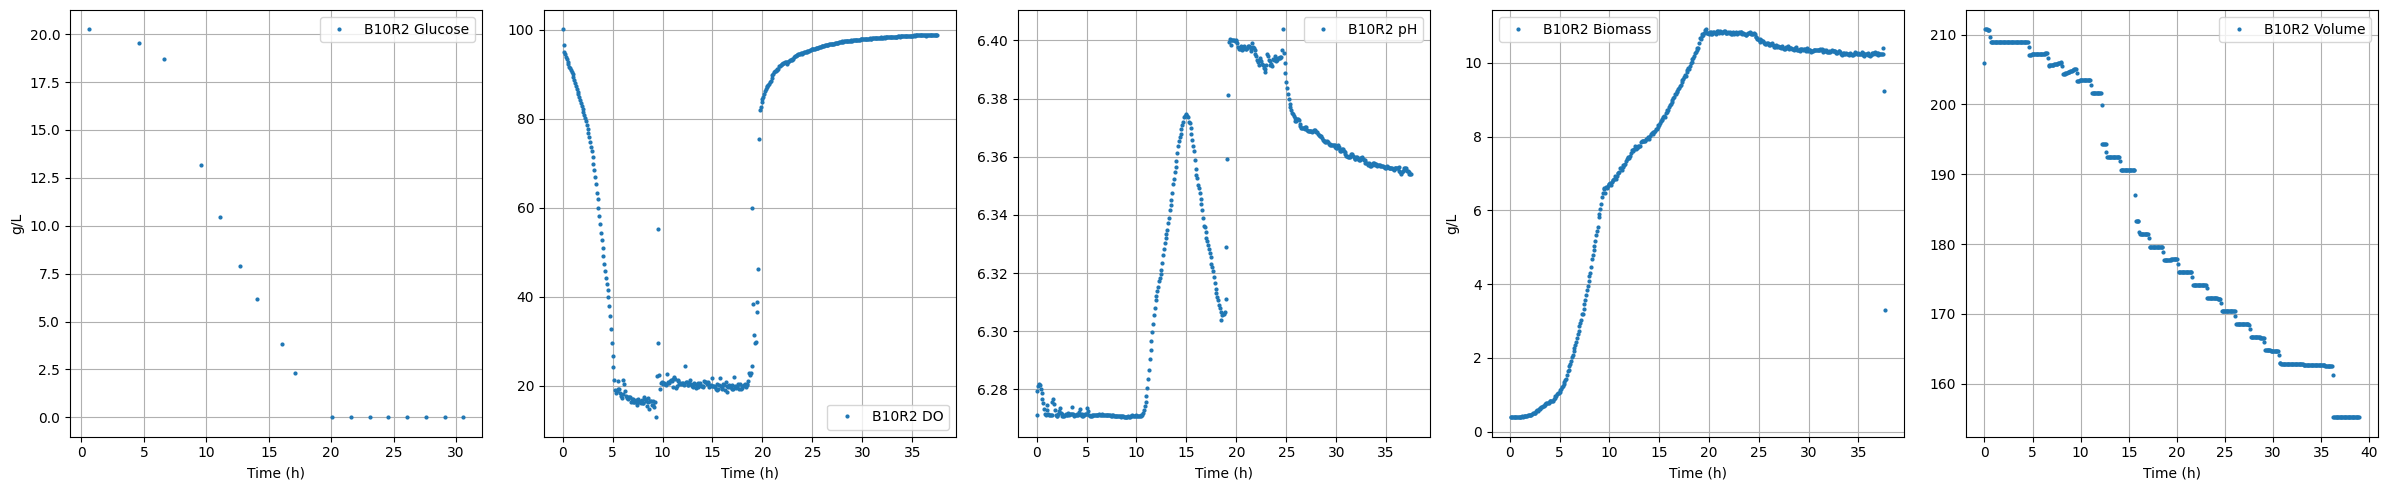

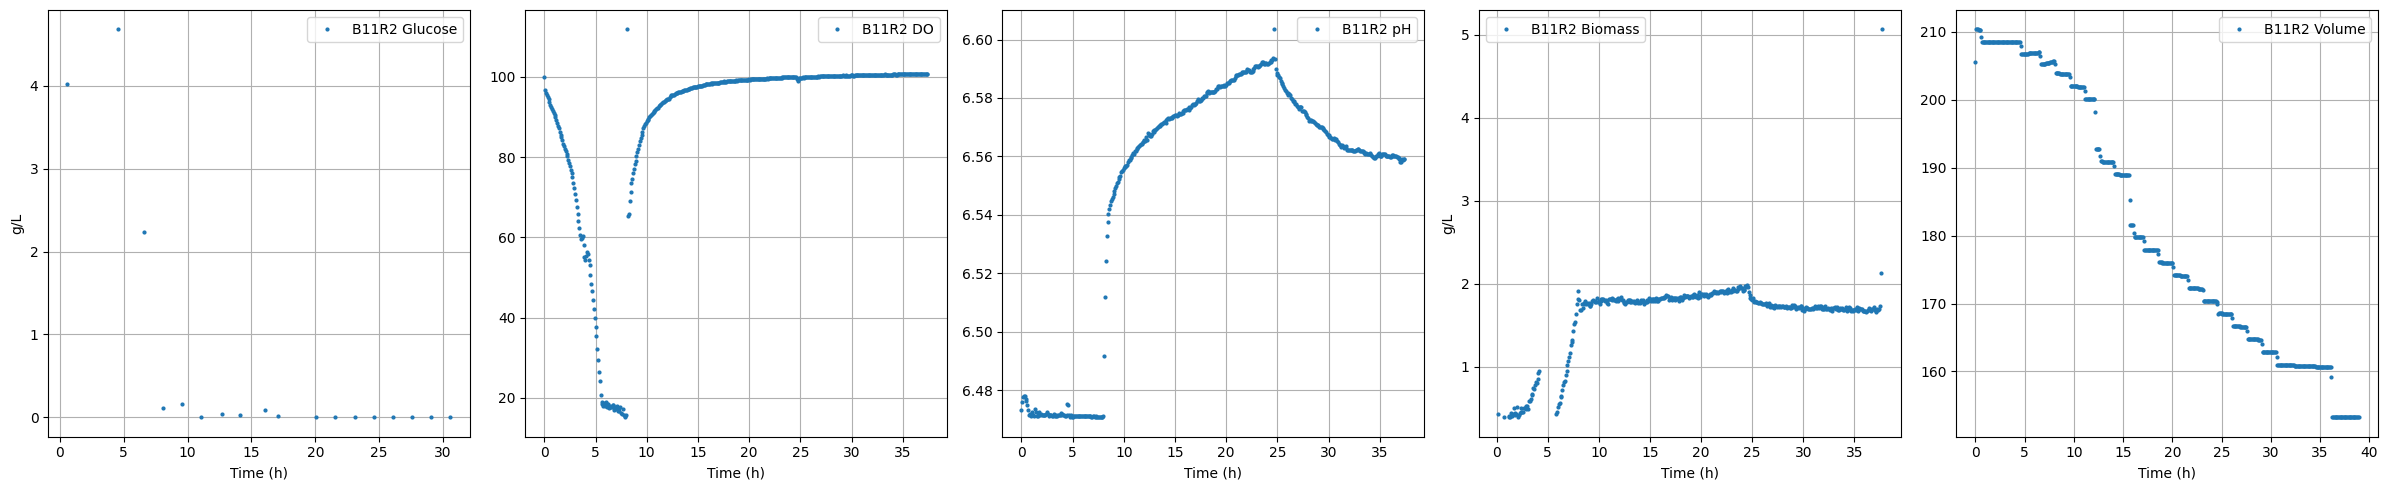

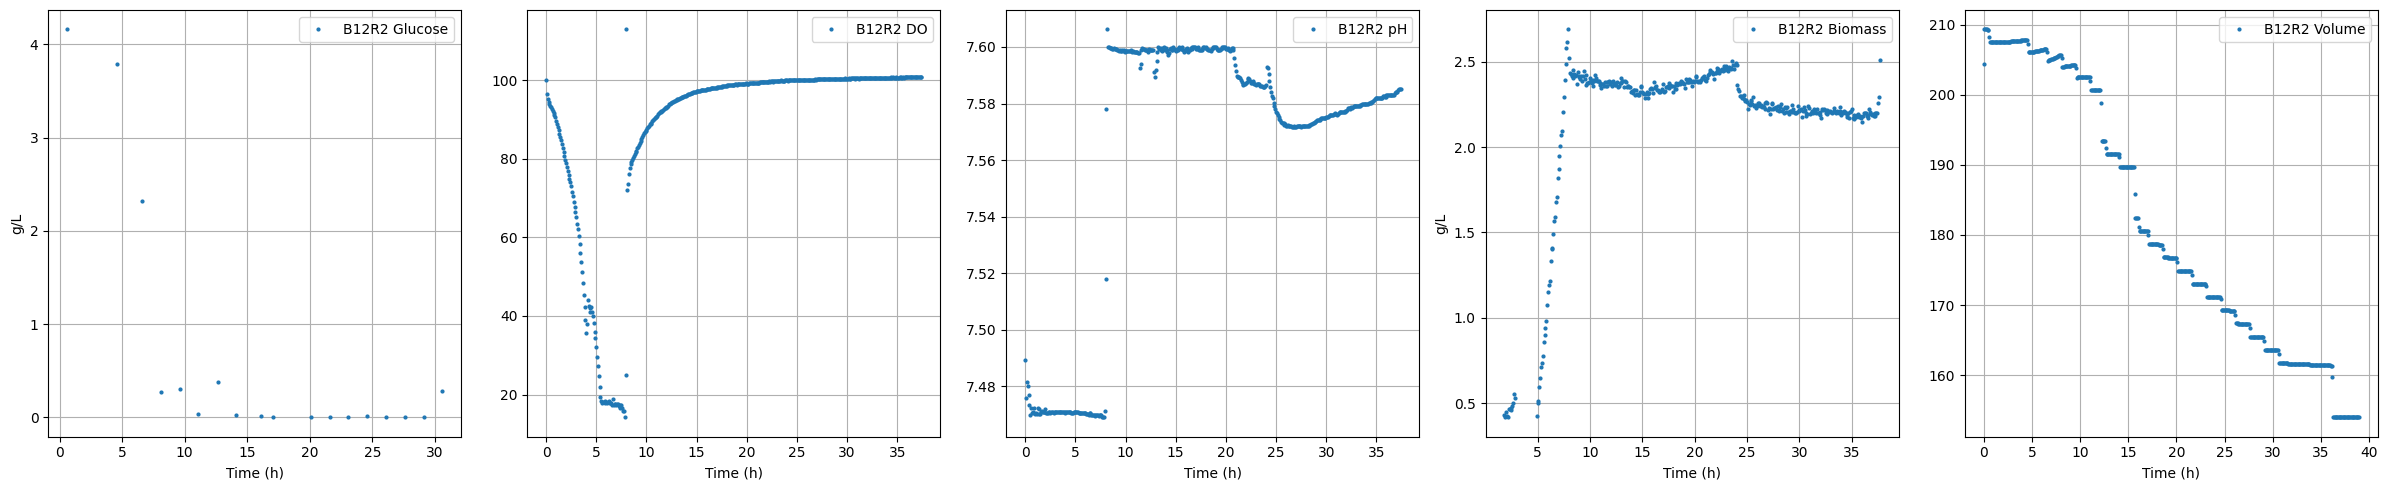

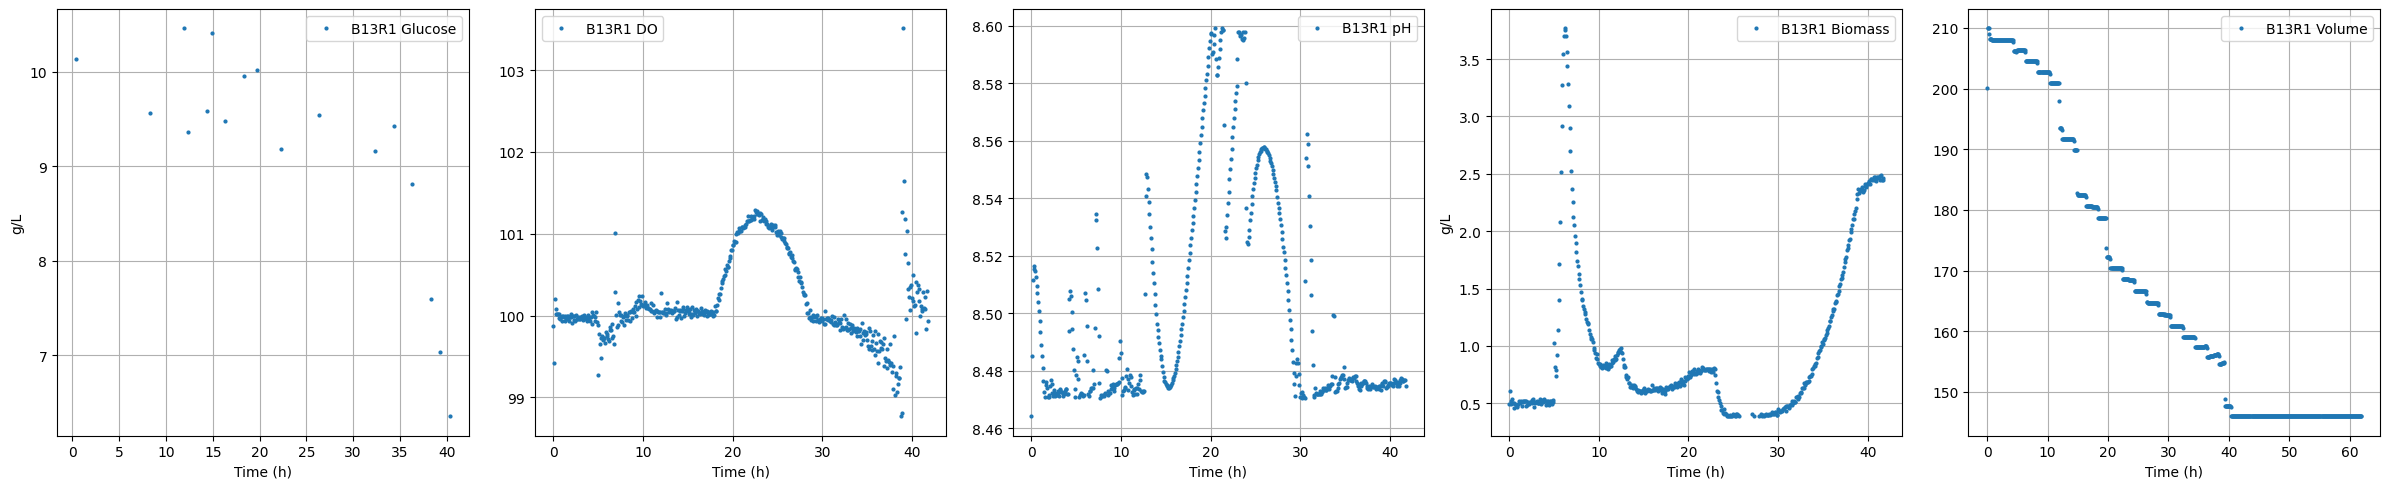

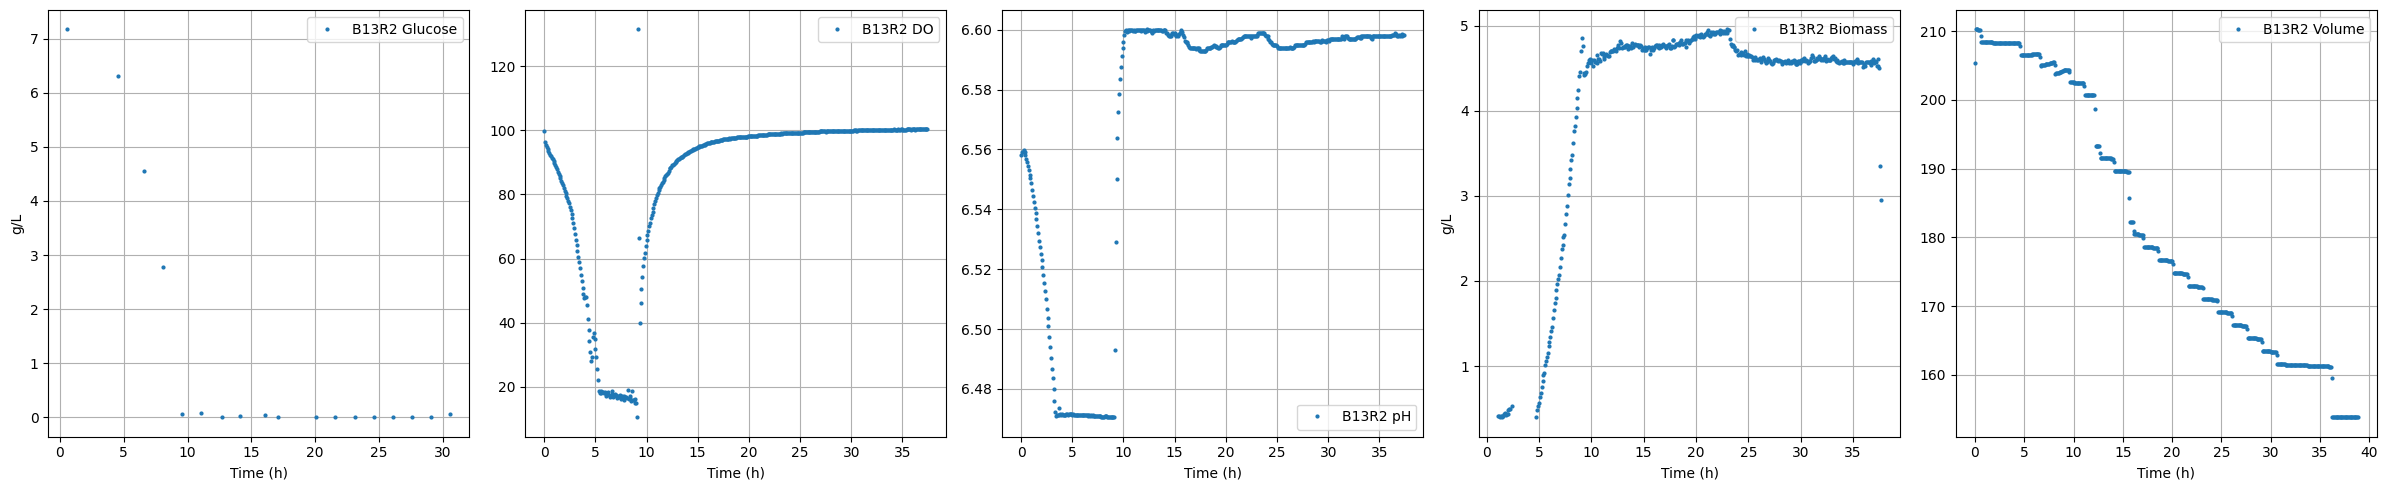

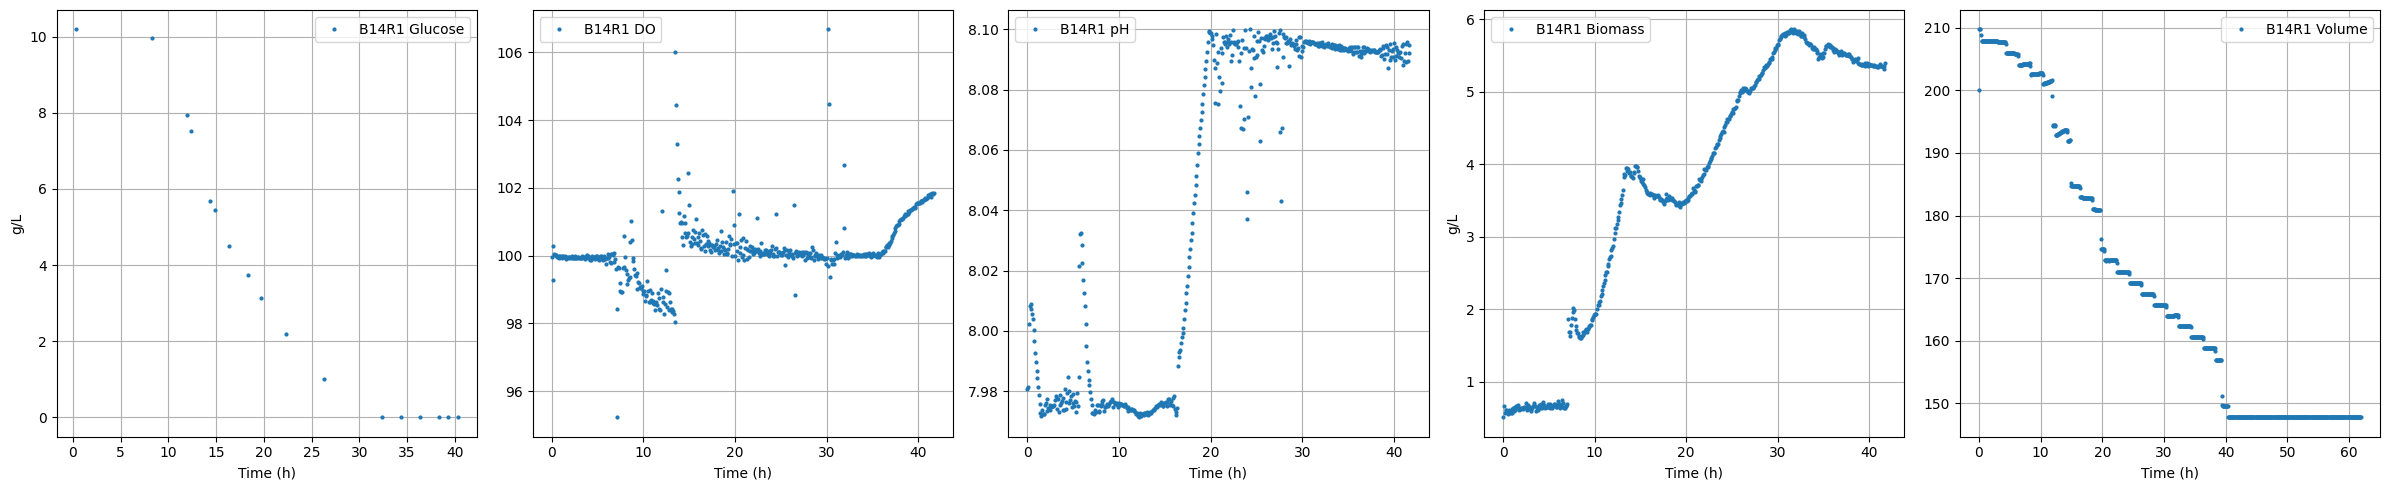

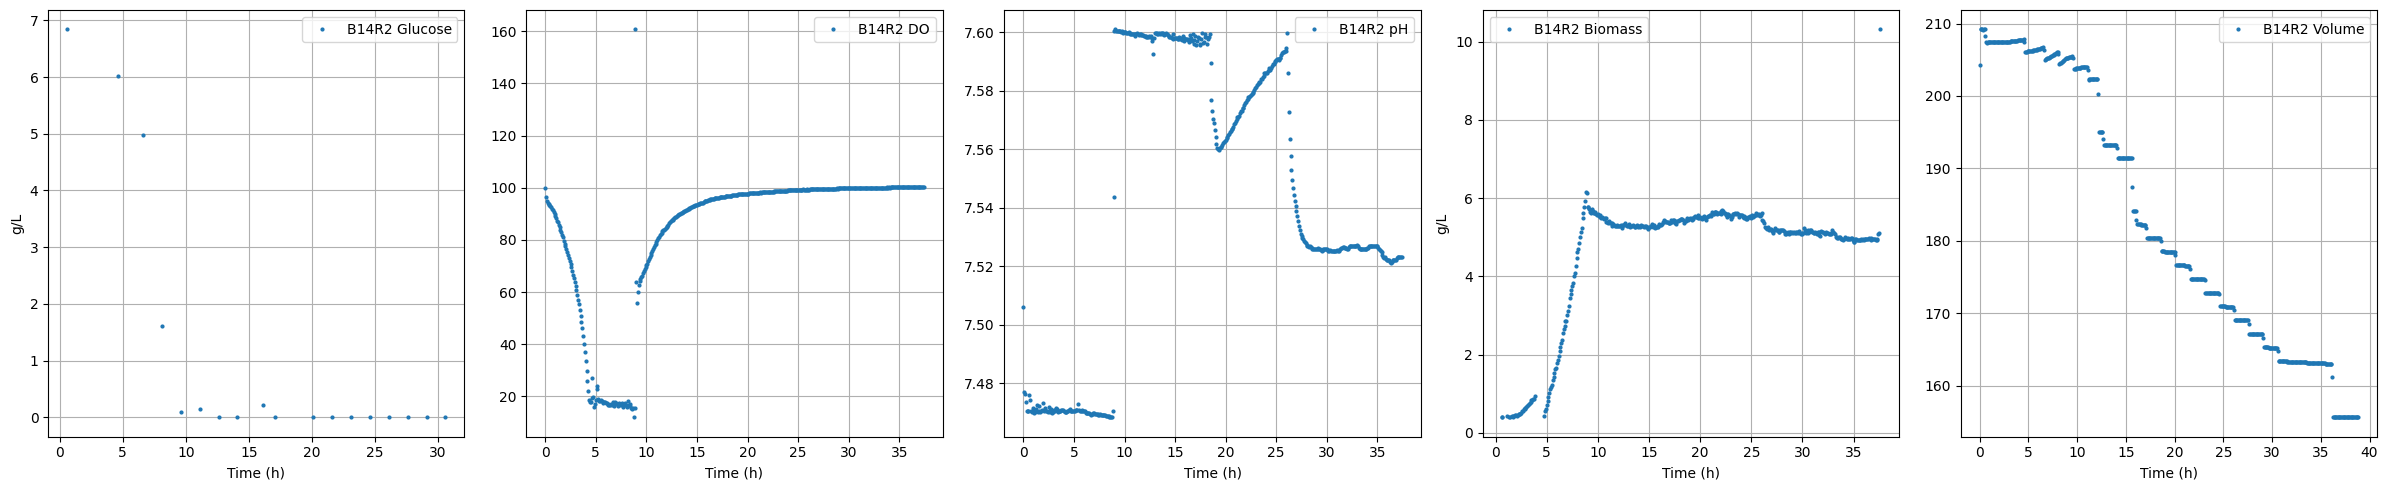

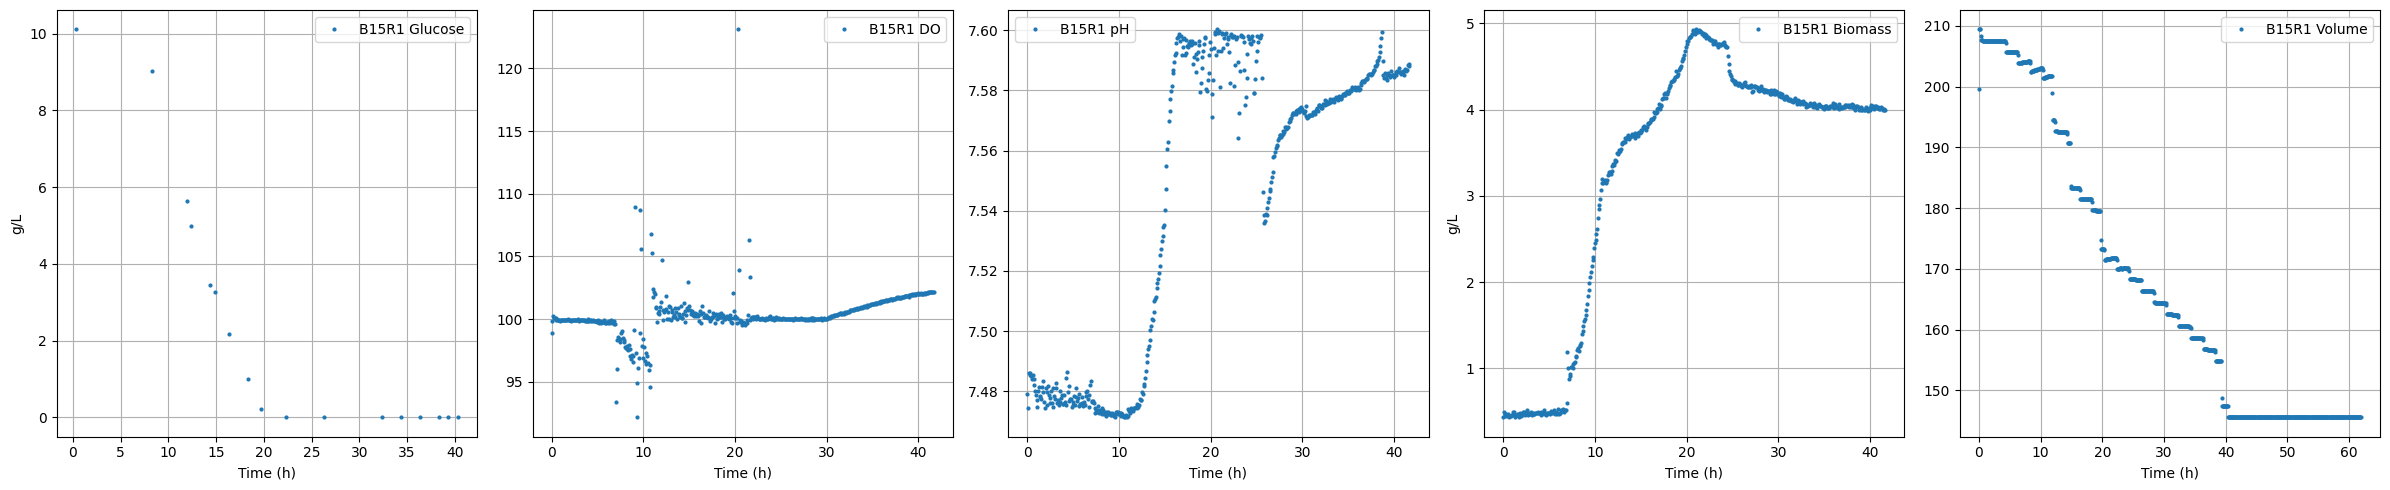

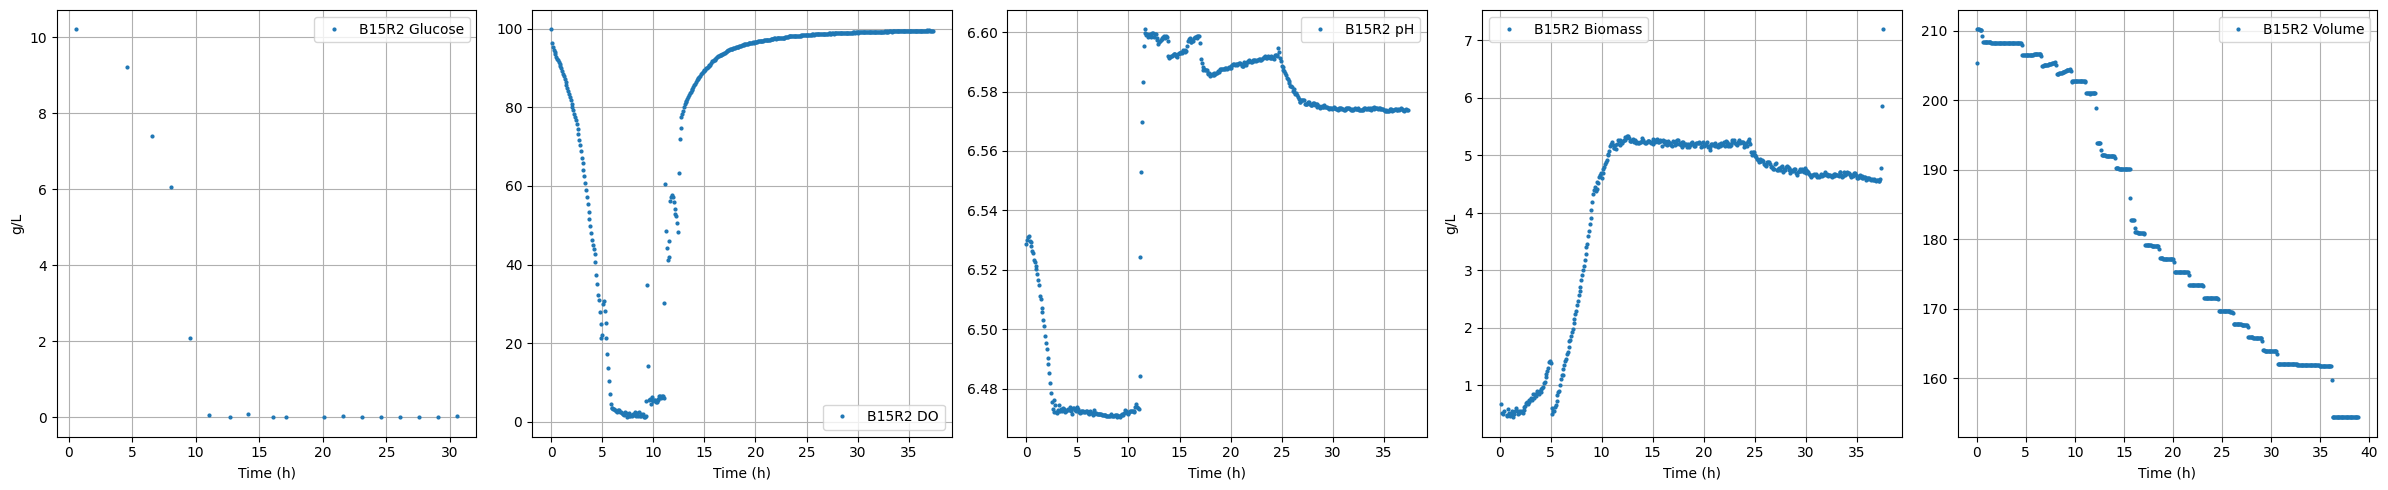

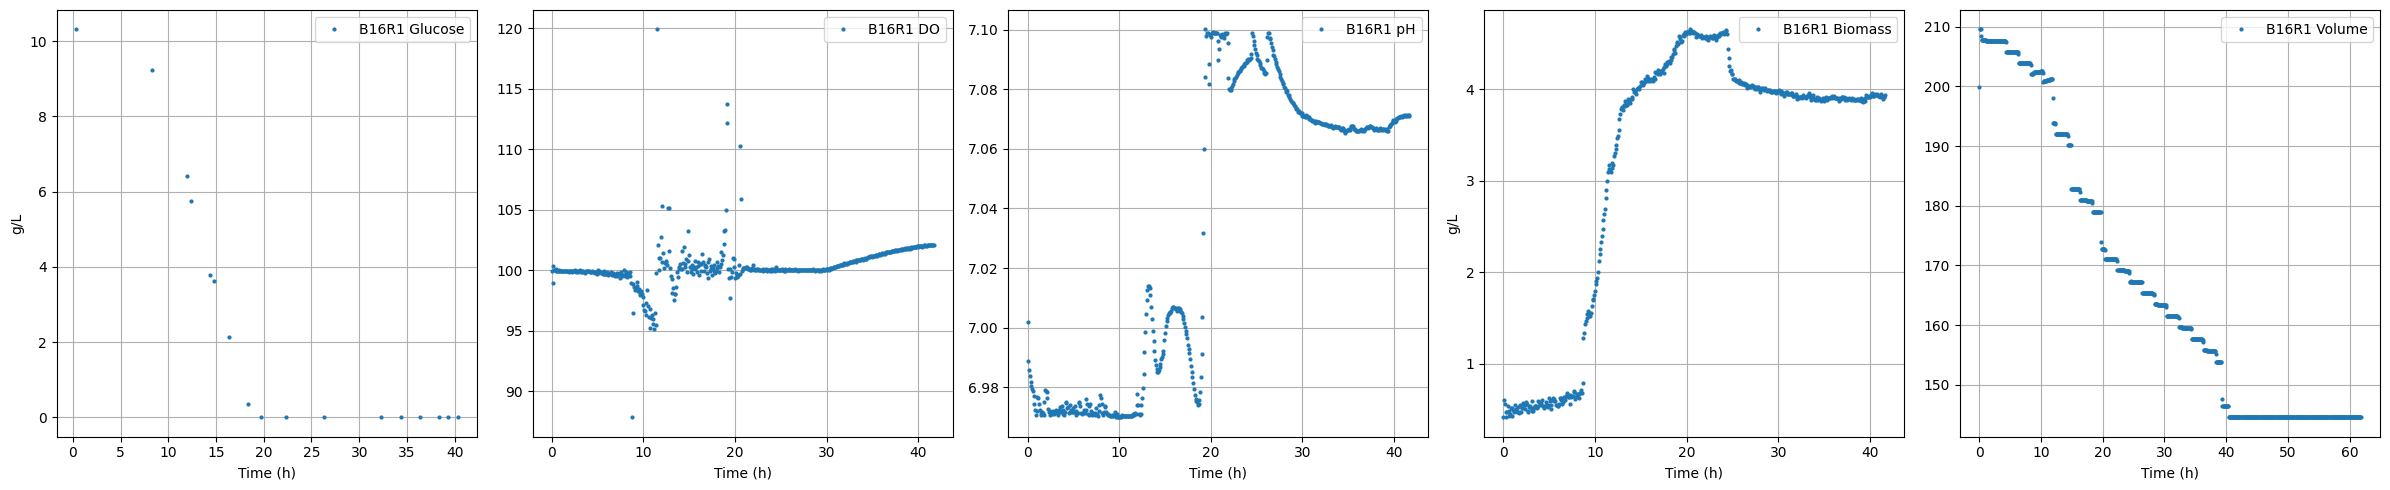

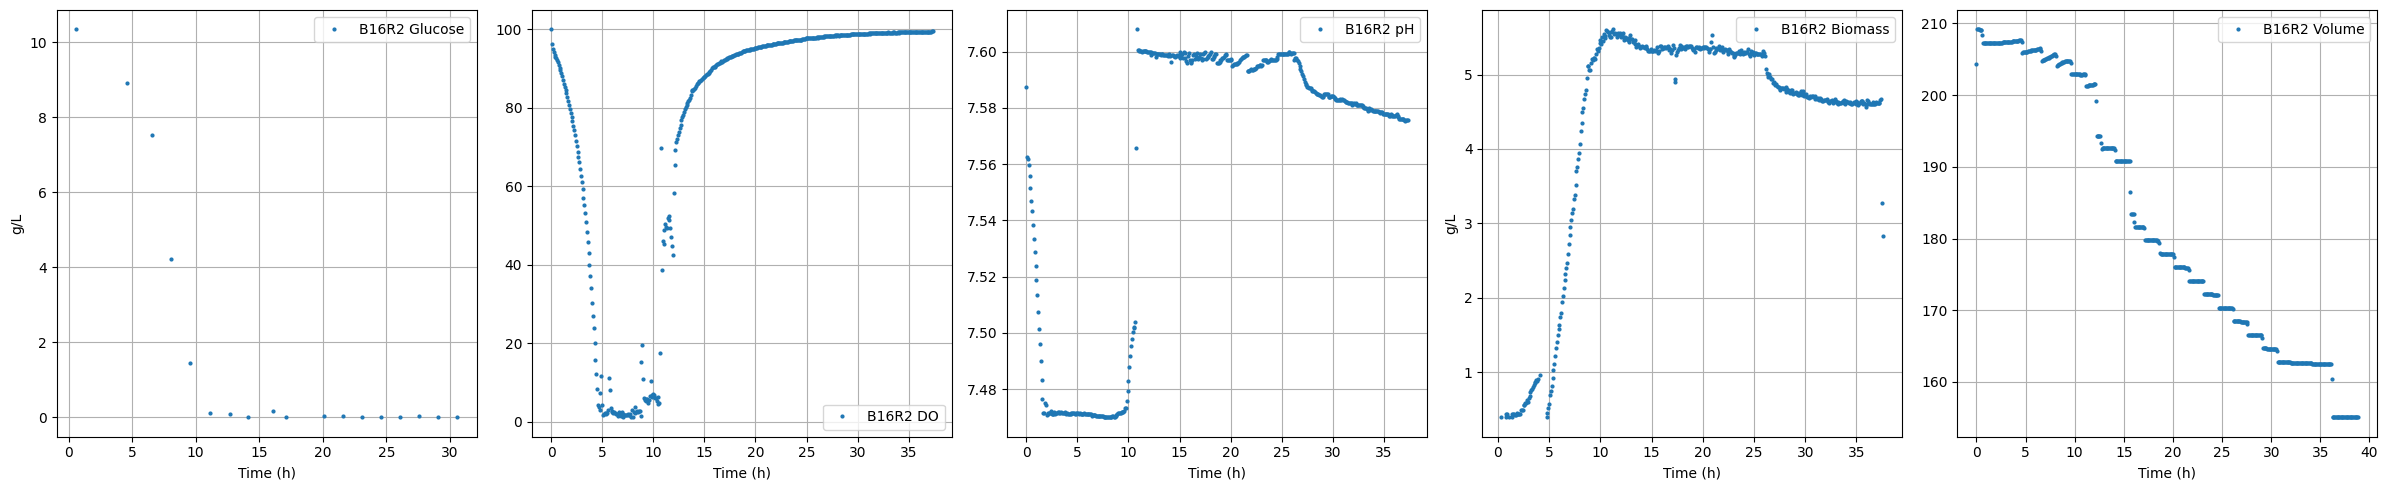

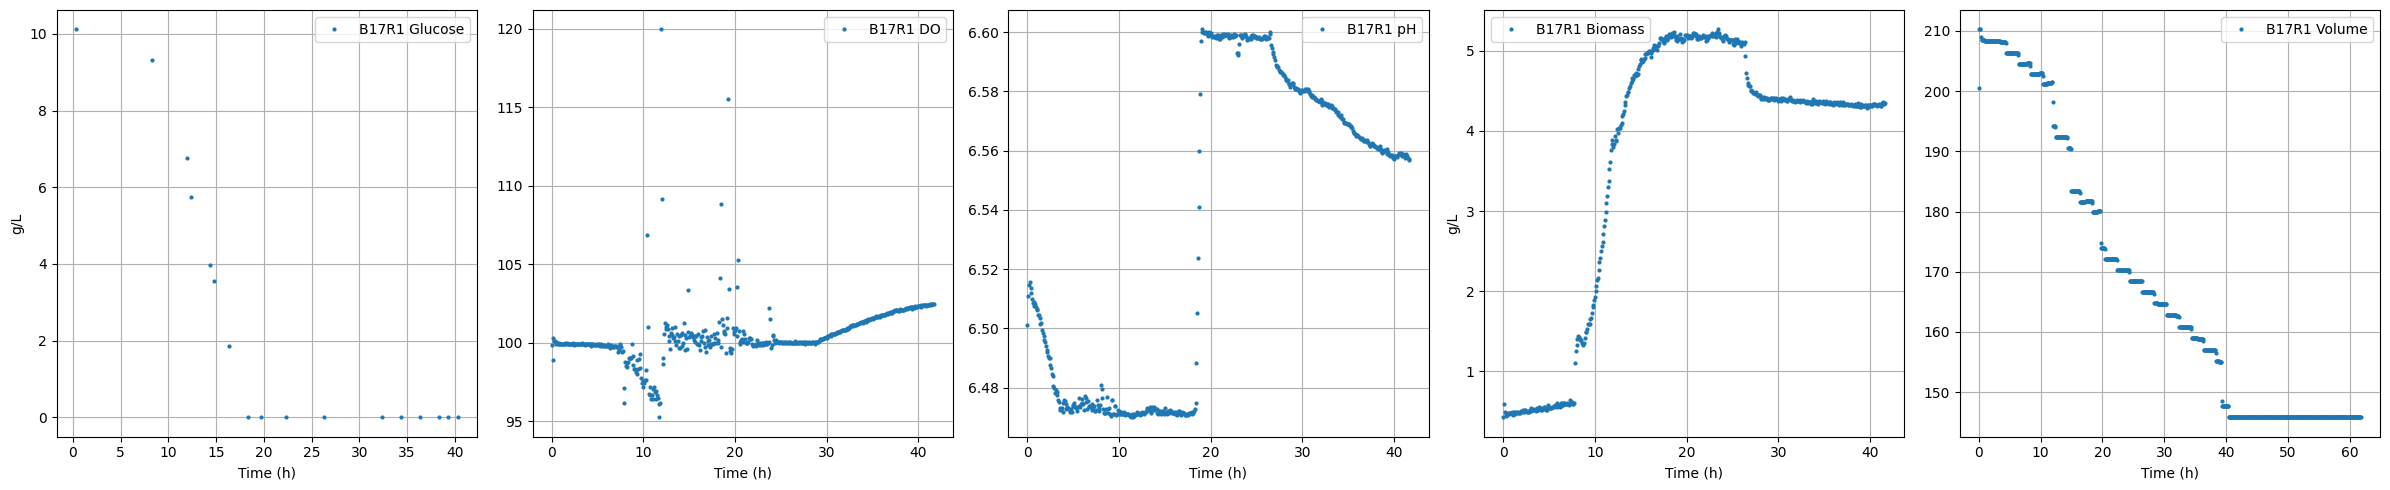

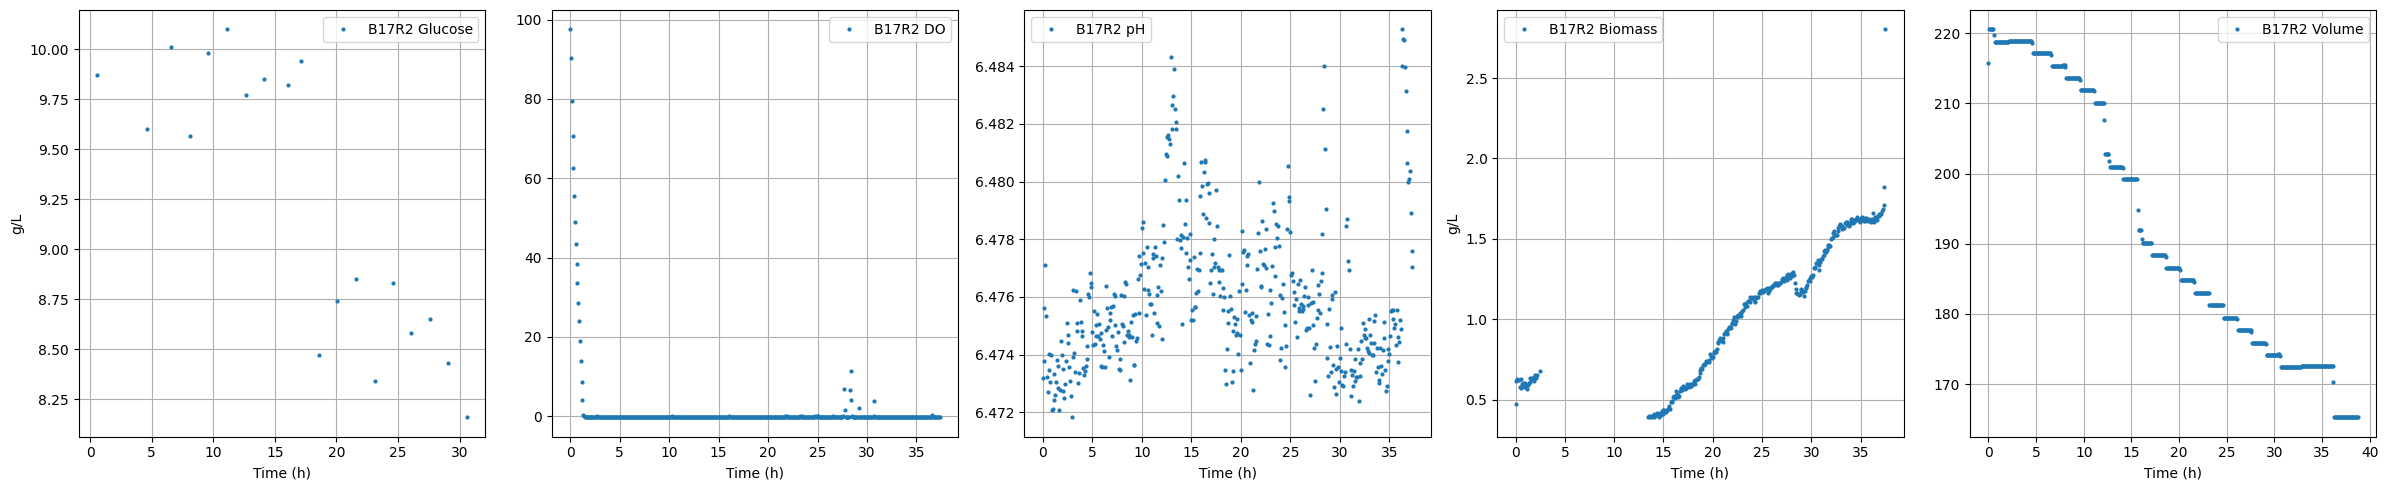

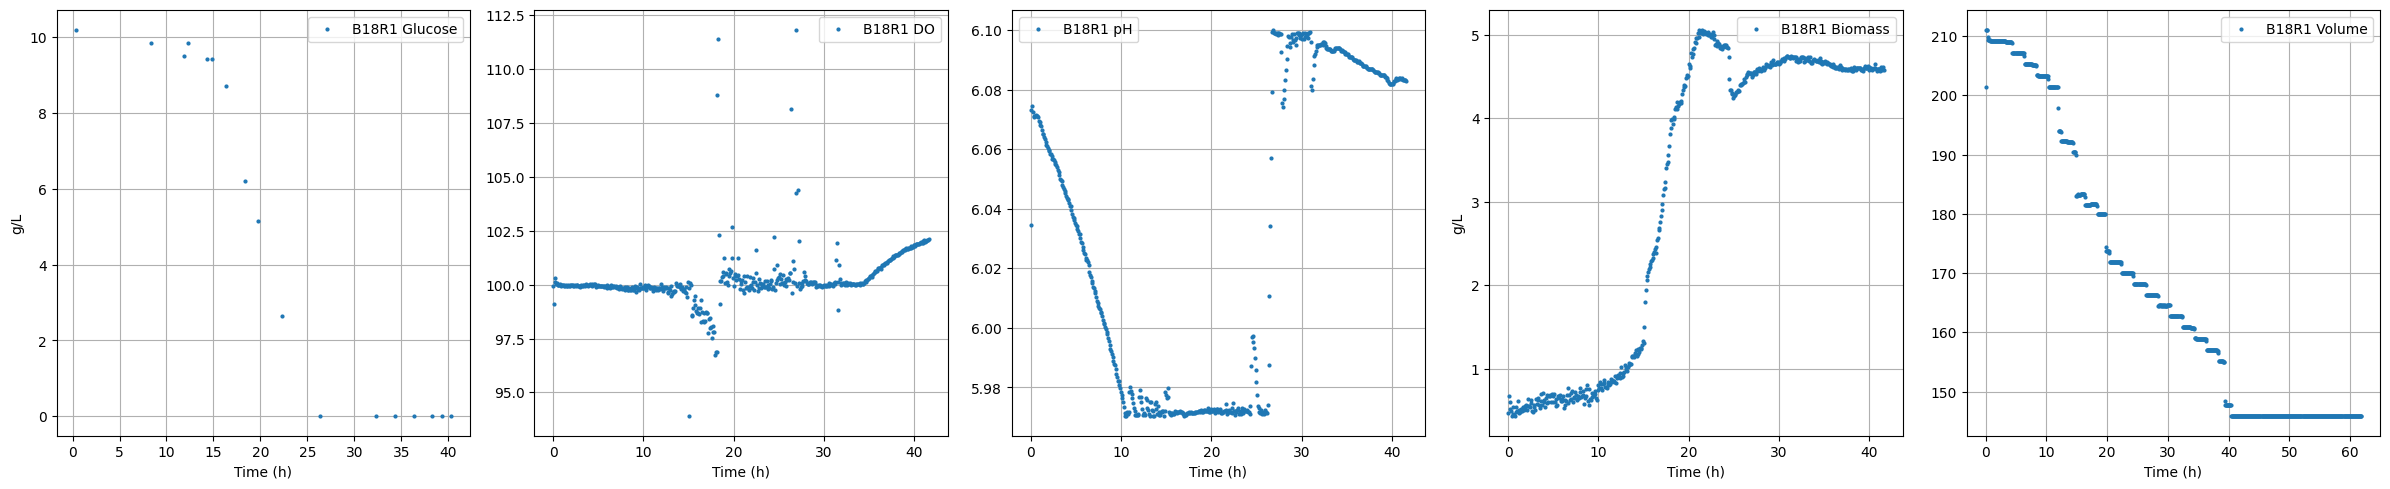

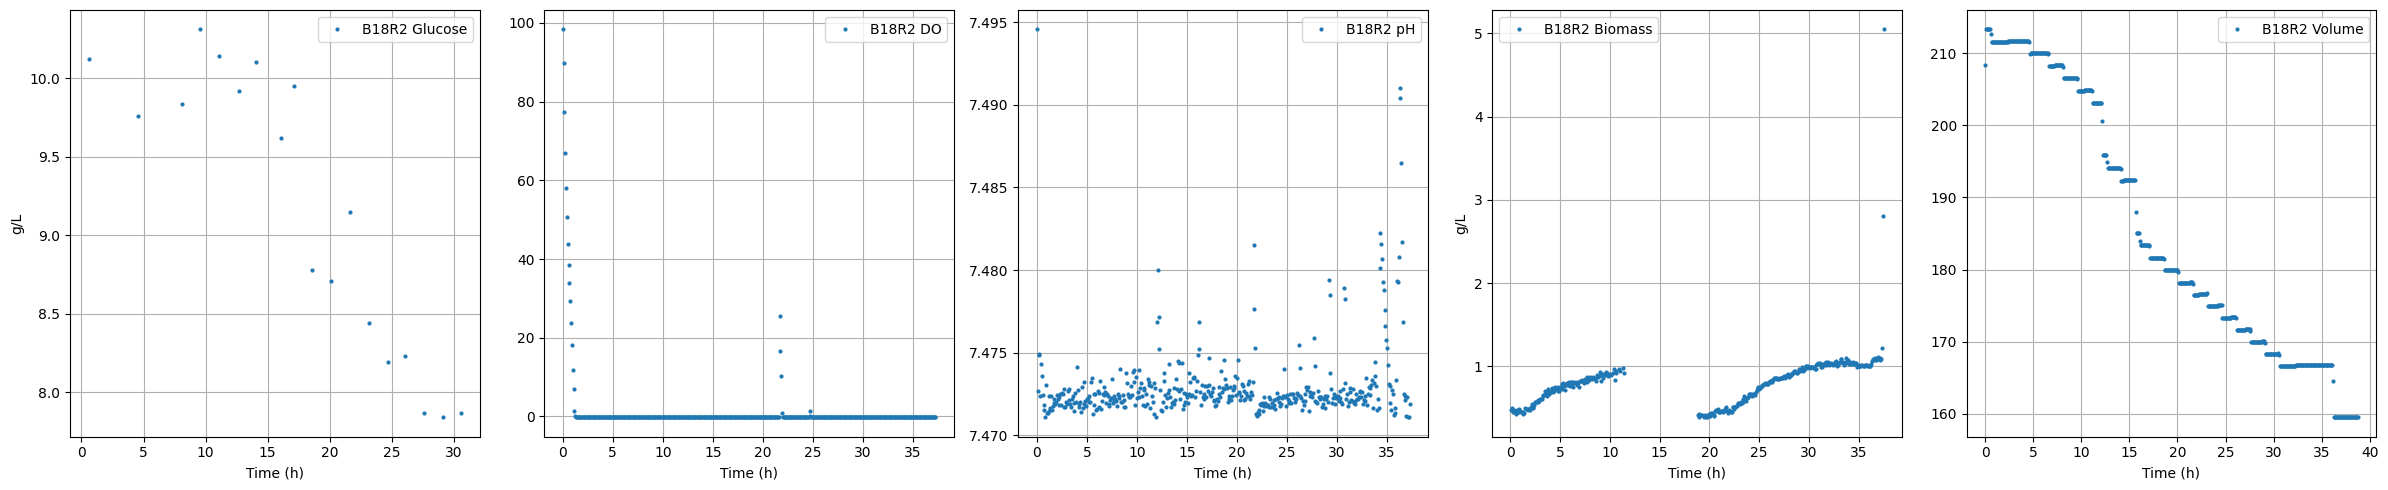

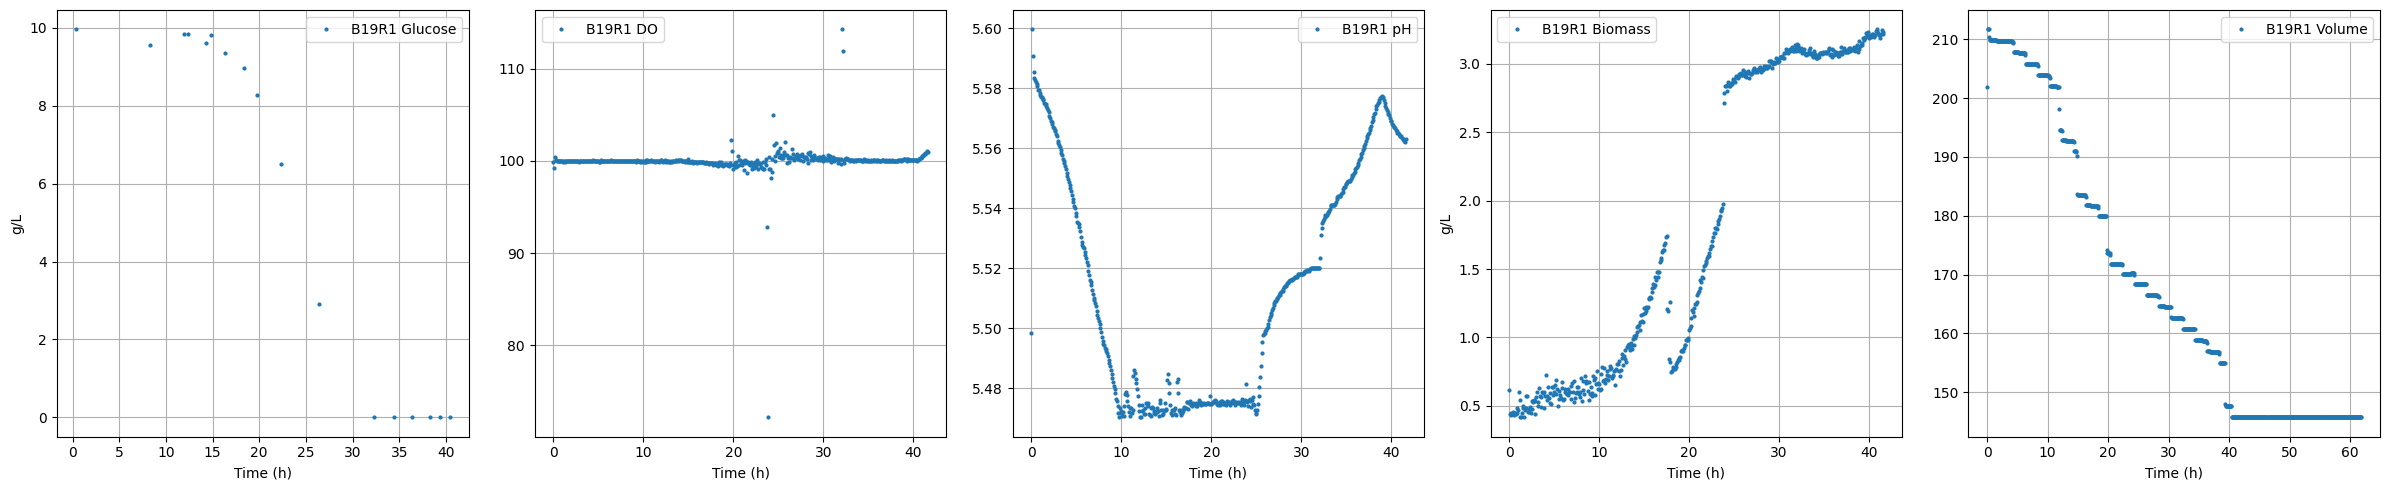

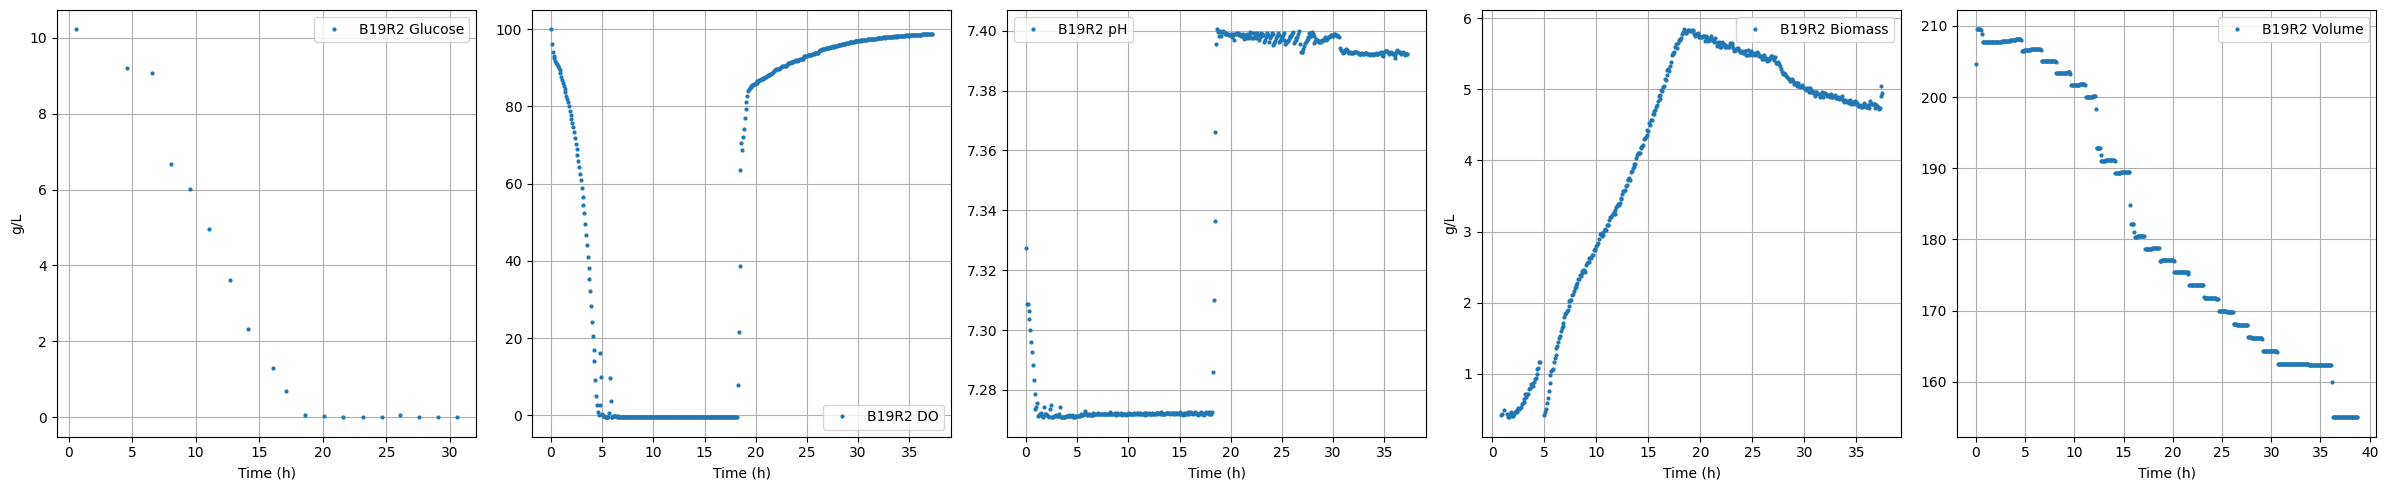

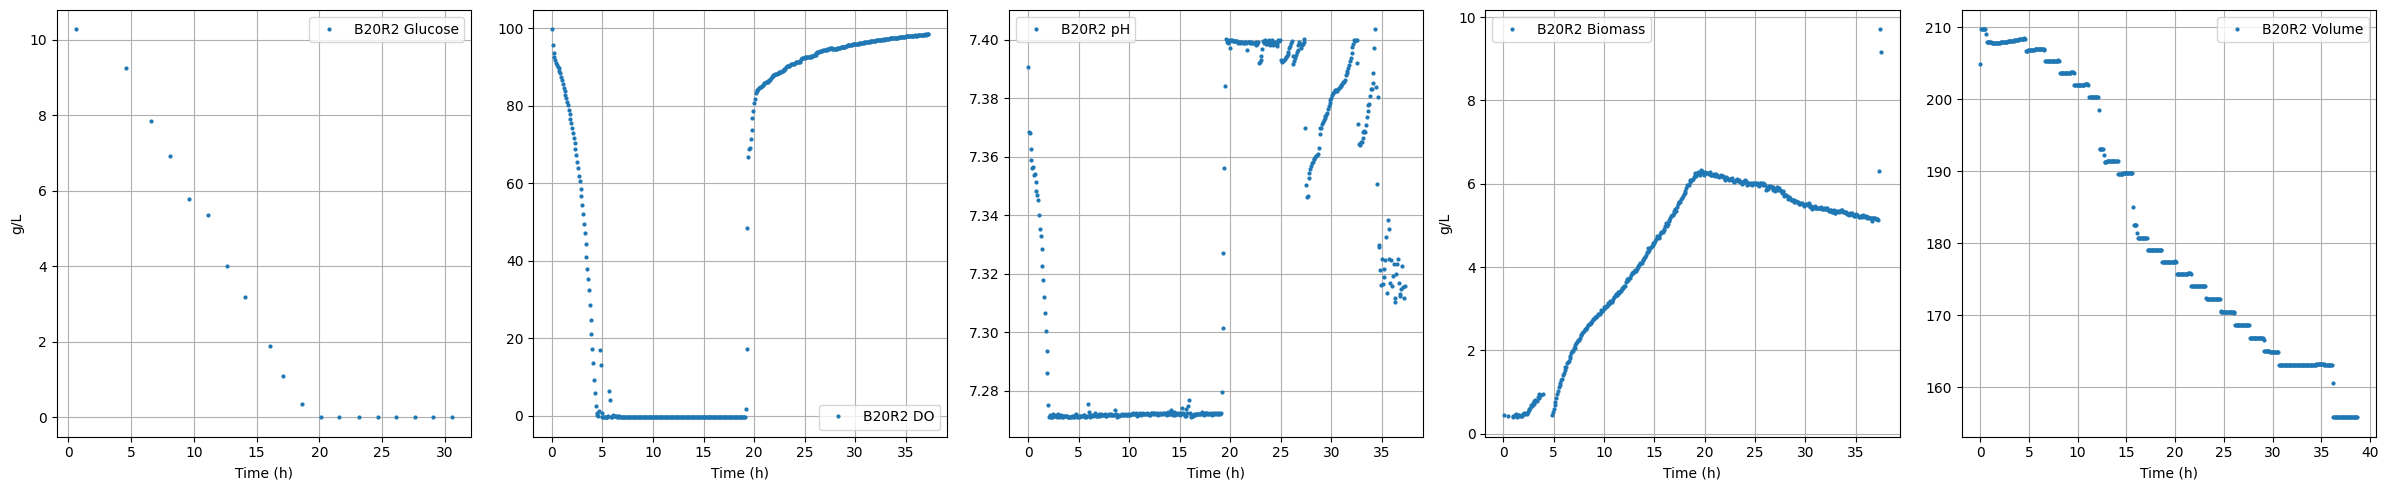

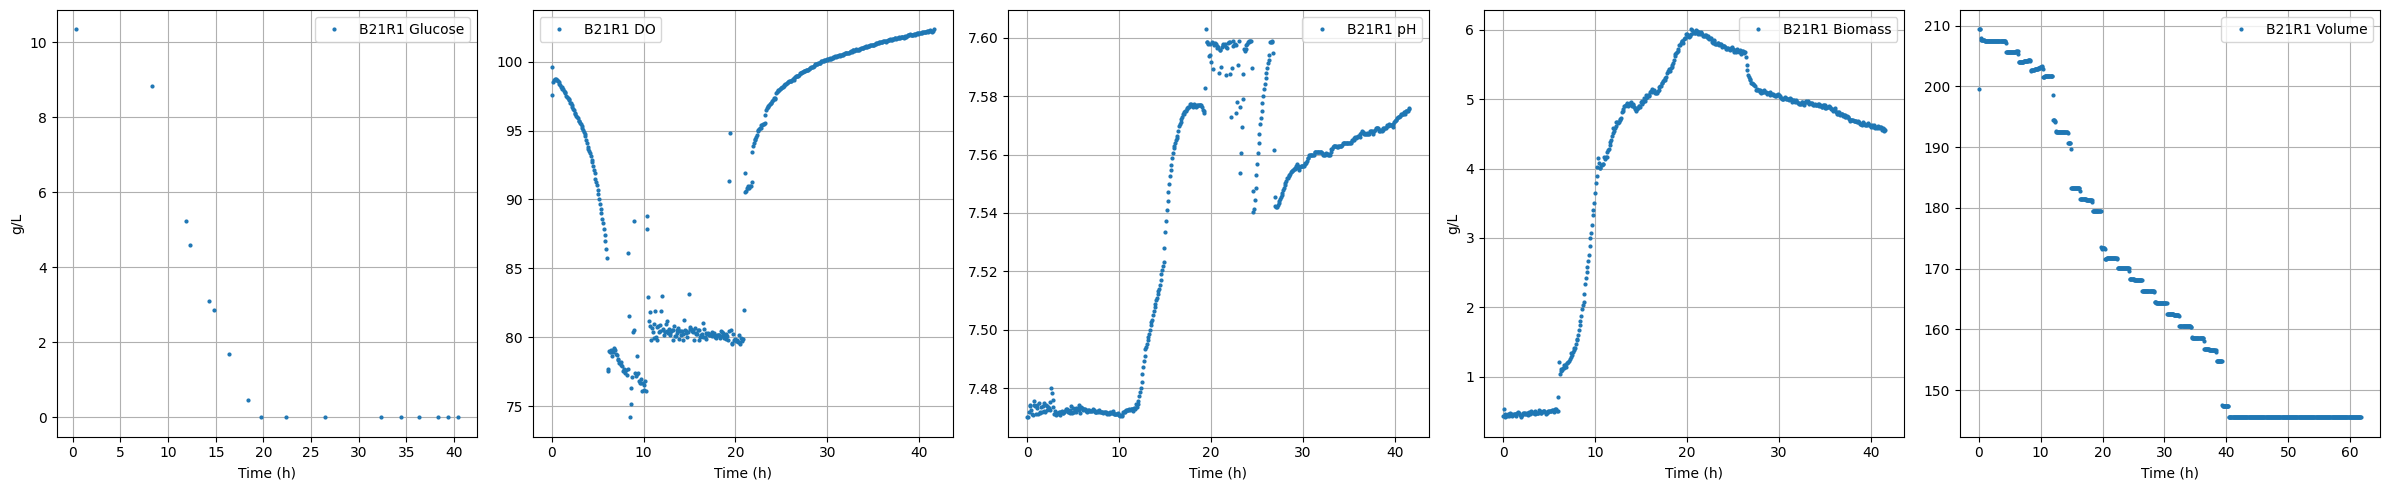

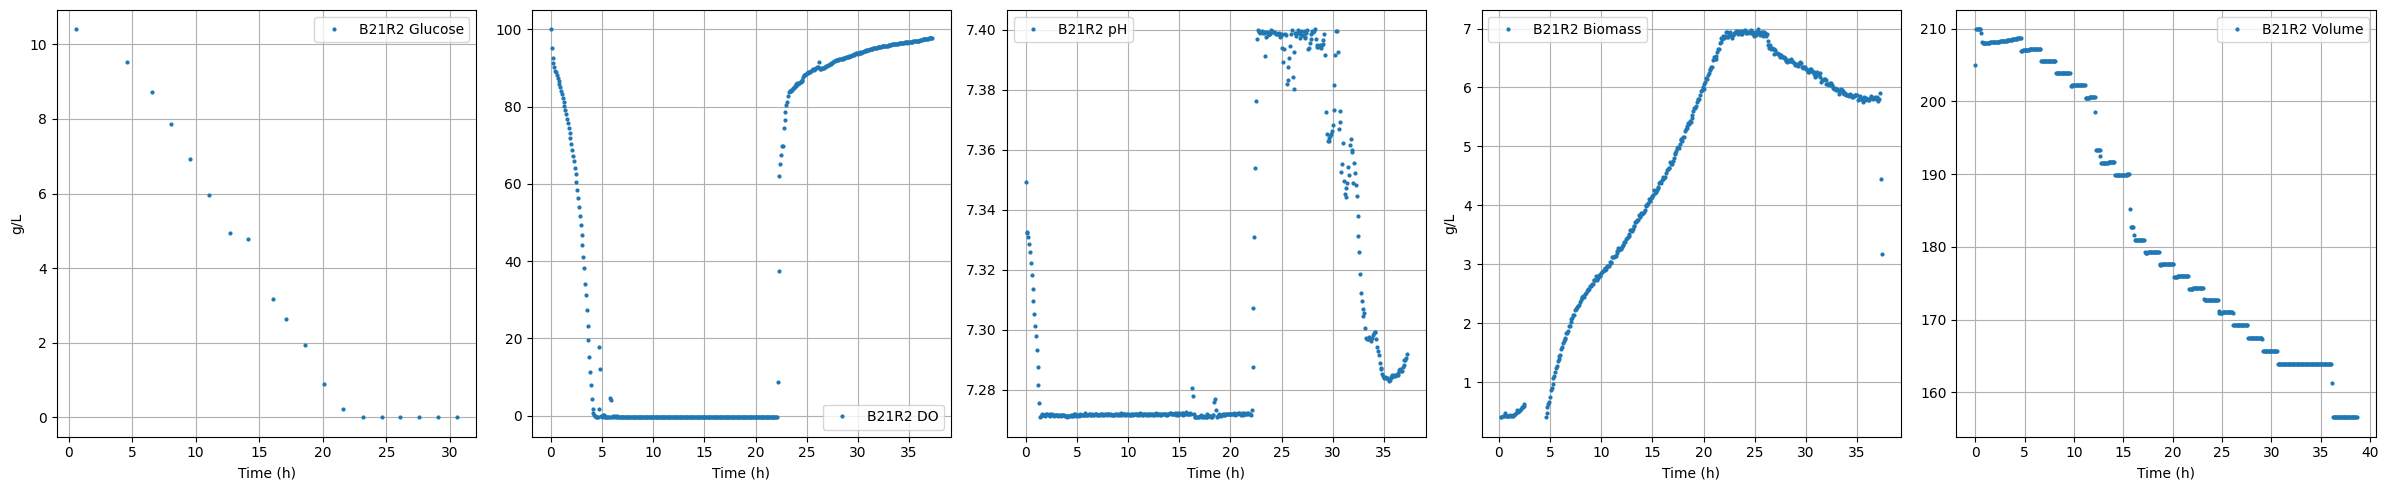

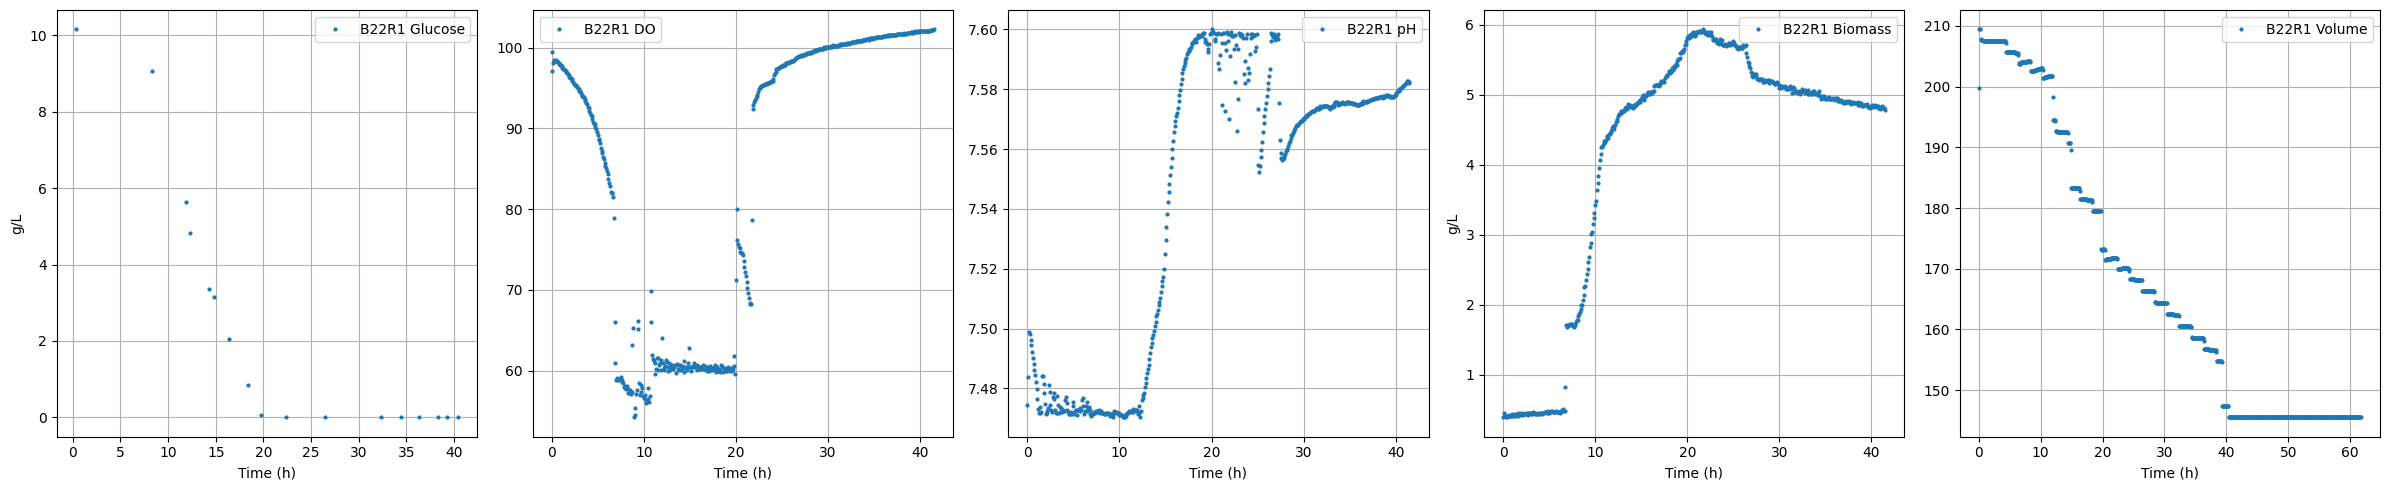

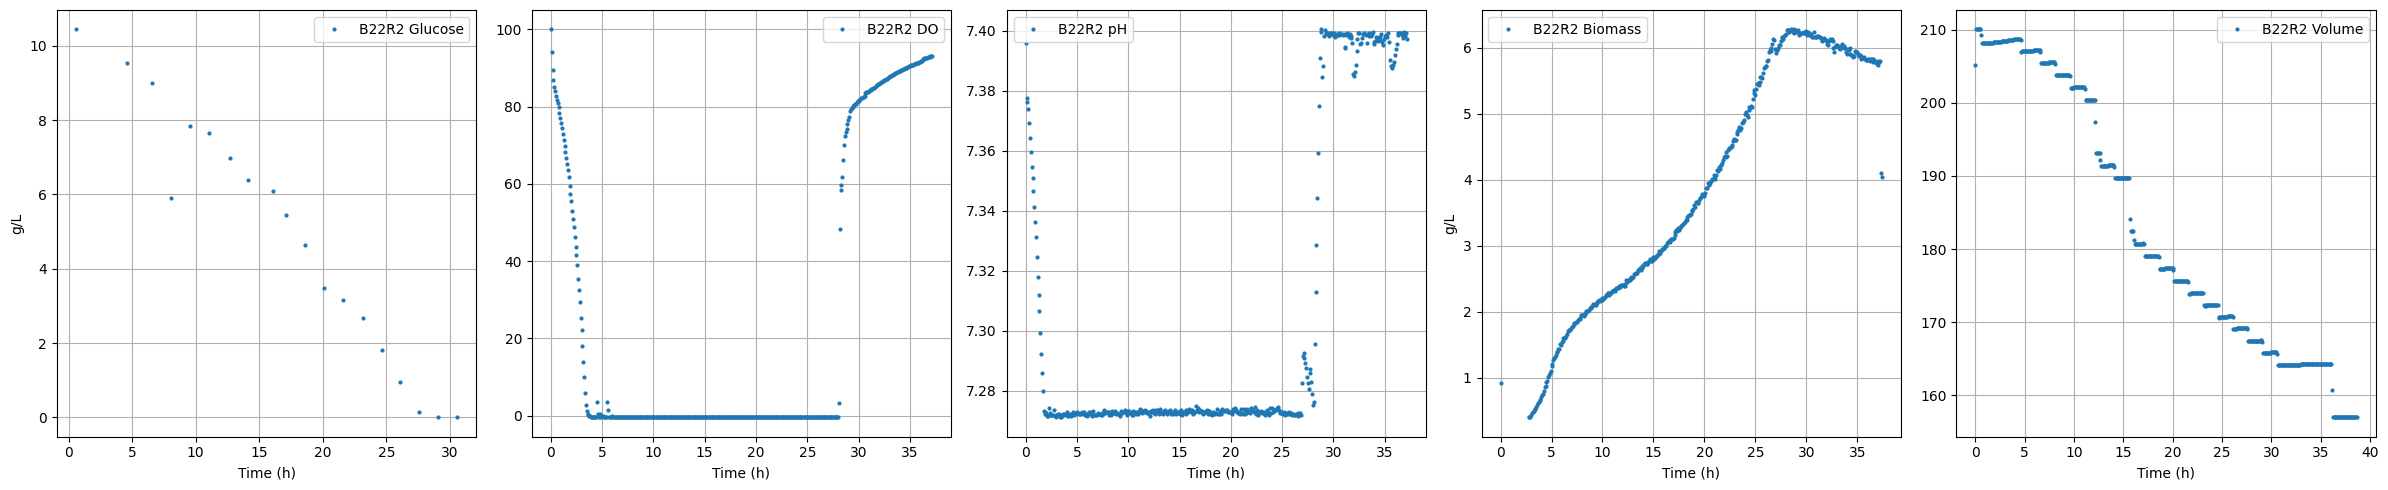

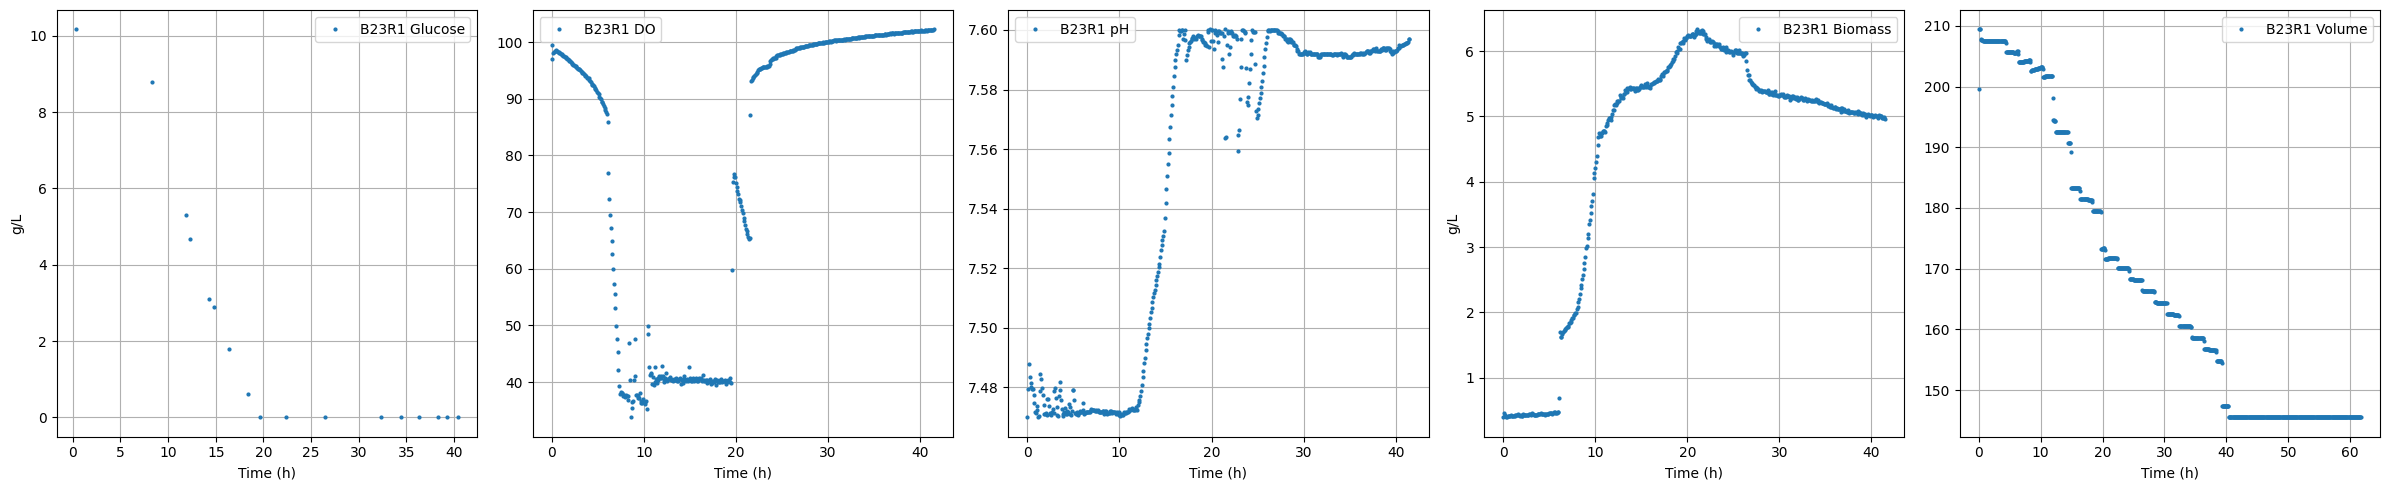

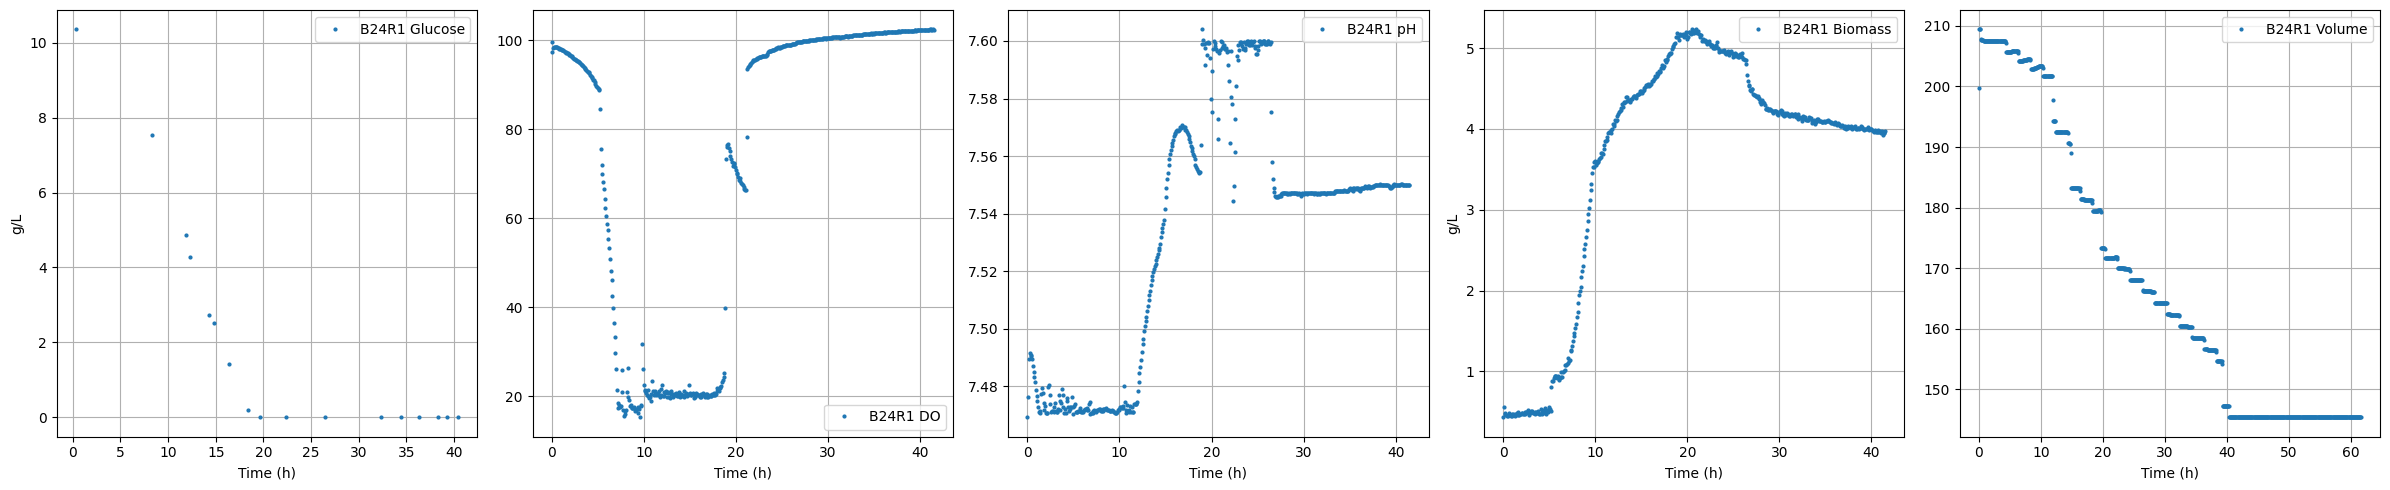

In [41]:
import matplotlib.pyplot as plt

var_names = ["Glucose", "DO", "pH", "Biomass", "Volume"]
units = ["g/L", "", "", "g/L", ""]
for bior in list(trajectory_store):
    # --- Plot predictions vs ground truth ---
    fig, axs = plt.subplots(1, 5, figsize=(24, 5))
    for var_idx, name in enumerate(var_names):
        axs[var_idx].plot(trajectory_store[bior][name][0],trajectory_store[bior][name][1], "o",label=bior + " " + name, linewidth=2, markersize=2)
        axs[var_idx].set_xlabel("Time (h)")
        axs[var_idx].set_ylabel(units[var_idx])
        axs[var_idx].legend()
        ymin, ymax = axs[var_idx].get_ylim()

        axs[var_idx].grid(True)

    plt.tight_layout()
    plt.show()


In [42]:
data_size = 5
lr = 1e-4 #Do not change
width_size = 17
depth = 6

In [43]:
import torch
import diffrax
import equinox as eqx
import jax
import jax.nn as jnn
import jax.random as jr
import optax
from tqdm import tqdm
import jax.numpy as jnp

class Func(eqx.Module):
    out_scale: jax.Array
    mlp: eqx.nn.MLP

    def __init__(self, data_size, width_size, depth, *, key, **kwargs):
        super().__init__(**kwargs)
        self.out_scale = jnp.array(1.0)
        self.mlp = eqx.nn.MLP(
            in_size=data_size,
            out_size=data_size,
            width_size=width_size,
            depth=depth,
            activation=jnn.softplus,
            final_activation=lambda x: x,
            key=key,
        )

    def __call__(self, t, y, args):
        return self.out_scale * self.mlp(y)

class NeuralODE(eqx.Module):
    func: Func

    def __init__(self, data_size, width_size, depth, *, key, **kwargs):
        super().__init__(**kwargs)
        self.func = Func(data_size, width_size, depth, key=key)

    def __call__(self, ts, y0):
        solution = diffrax.diffeqsolve(
            diffrax.ODETerm(self.func),
            diffrax.Dopri5(),
            t0=ts[0],
            t1=ts[-1],
            dt0=ts[1] - ts[0],
            y0=y0,
            stepsize_controller=diffrax.PIDController(rtol=1e-4, atol=1e-6),
            adjoint=diffrax.DirectAdjoint(),
            max_steps=1000000,
            saveat=diffrax.SaveAt(ts=ts),
        )
        return solution.ys
    
def main(n_epochs, seed=5678):

    key = jr.PRNGKey(seed)
    data_key, model_key, loader_key = jr.split(key, 3)

    model = NeuralODE(data_size, width_size, depth, key=model_key)
    optim = optax.adabelief(lr)
    """optim = optax.chain(
    optax.clip_by_global_norm(1.0),
    optax.adam(lr))"""
    opt_state = optim.init(eqx.filter(model, eqx.is_inexact_array))

    @eqx.filter_value_and_grad
    def grad_loss(model, ti, yi):
        y_pred = model(ti, yi[0])  # shape (T, data_size)
        sigma = 1.0
        loss_classic = jnp.mean(((yi - y_pred) / sigma) ** 2)
        negativity_loss = jnp.mean(jnp.maximum(0.0, -y_pred) ** 2)
        return loss_classic + negativity_loss

    @eqx.filter_jit
    def make_step(ti, yi, model, opt_state):
        loss, grads = grad_loss(model, ti, yi)
        updates, opt_state = optim.update(grads, opt_state, model)
        model = eqx.apply_updates(model, updates)
        return loss, model, opt_state

    loss_l = []
    n_vars = 4
    R2_scores = [[] for _ in range(n_vars)]

    # number of bioreactors = total entries / 4 variables each
    o = len(list(trajectory_store))

    for epoch in tqdm(range(n_epochs)):
        list(trajectory_store)
        idx = epoch % o

        bior = list(trajectory_store)[idx]
        if bior == bior_test:
            continue

        # Get the 4 variables for this bioreactor
        glc_ys  = trajectory_store[bior]['Glucose'][1]
        od_ys   = trajectory_store[bior]['DO'][1]
        ph_ys   = trajectory_store[bior]['pH'][1]
        bio_ys  = trajectory_store[bior]['Biomass'][1]
        vol_ys = trajectory_store[bior]['Volume'][1]

        # Get the corresponding time arrays
        glc_ts  = trajectory_store[bior]['Glucose'][0]
        od_ts   = trajectory_store[bior]['DO'][0]
        ph_ts   = trajectory_store[bior]['pH'][0]
        bio_ts  = trajectory_store[bior]['Biomass'][0]
        vol_ts = trajectory_store[bior]['Volume'][0]

        # Use OD timestamps as the common time grid
        t = jnp.asarray(od_ts, dtype=jnp.float32)

        # Interpolate all variables onto the OD time grid
        ys = jnp.stack([
            jnp.interp(t, jnp.asarray(glc_ts), jnp.asarray(glc_ys)),  # glucose
            jnp.asarray(od_ys,  dtype=jnp.float32),                    # OD (reference)
            jnp.interp(t, jnp.asarray(ph_ts),  jnp.asarray(ph_ys)),   # pH
            jnp.interp(t, jnp.asarray(bio_ts), jnp.asarray(bio_ys)),  # biomass
            jnp.interp(t, jnp.asarray(vol_ts), jnp.asarray(vol_ys)),
        ], axis=1)  # shape (T, 5)

        y_true = torch.tensor(np.asarray(ys), dtype=torch.float32)

        loss, model, opt_state = make_step(t, ys, model, opt_state)

        y_pred = torch.tensor(np.asarray(model(t, ys[0])), dtype=torch.float32)

        loss_l.append(float(loss))

        for var_idx in range(n_vars):
            ss_res = torch.sum((y_true[:, var_idx] - y_pred[:, var_idx]) ** 2)
            ss_tot = torch.sum((y_true[:, var_idx] - torch.mean(y_true[:, var_idx])) ** 2)
            r2 = 1 - ss_res / (ss_tot + 1e-12)
            R2_scores[var_idx].append(float(r2))

    return loss_l, R2_scores, t, ys, model
    
def normalize(ys, stats):
    result = []
    for i, y in enumerate(ys):
        var = i % 4
        key = ["glucose", "od", "ph", "biomass"][var]
        vmin, vmax = stats[key]
        result.append((y - vmin) / (vmax - vmin + 1e-8))
    return result

In [44]:
n_epochs = 50000

loss, R, t, ys, model = main(n_epochs)

100%|██████████| 50000/50000 [21:48<00:00, 38.20it/s]


In [45]:
list(trajectory_store)[bior_test]

'B24R1'

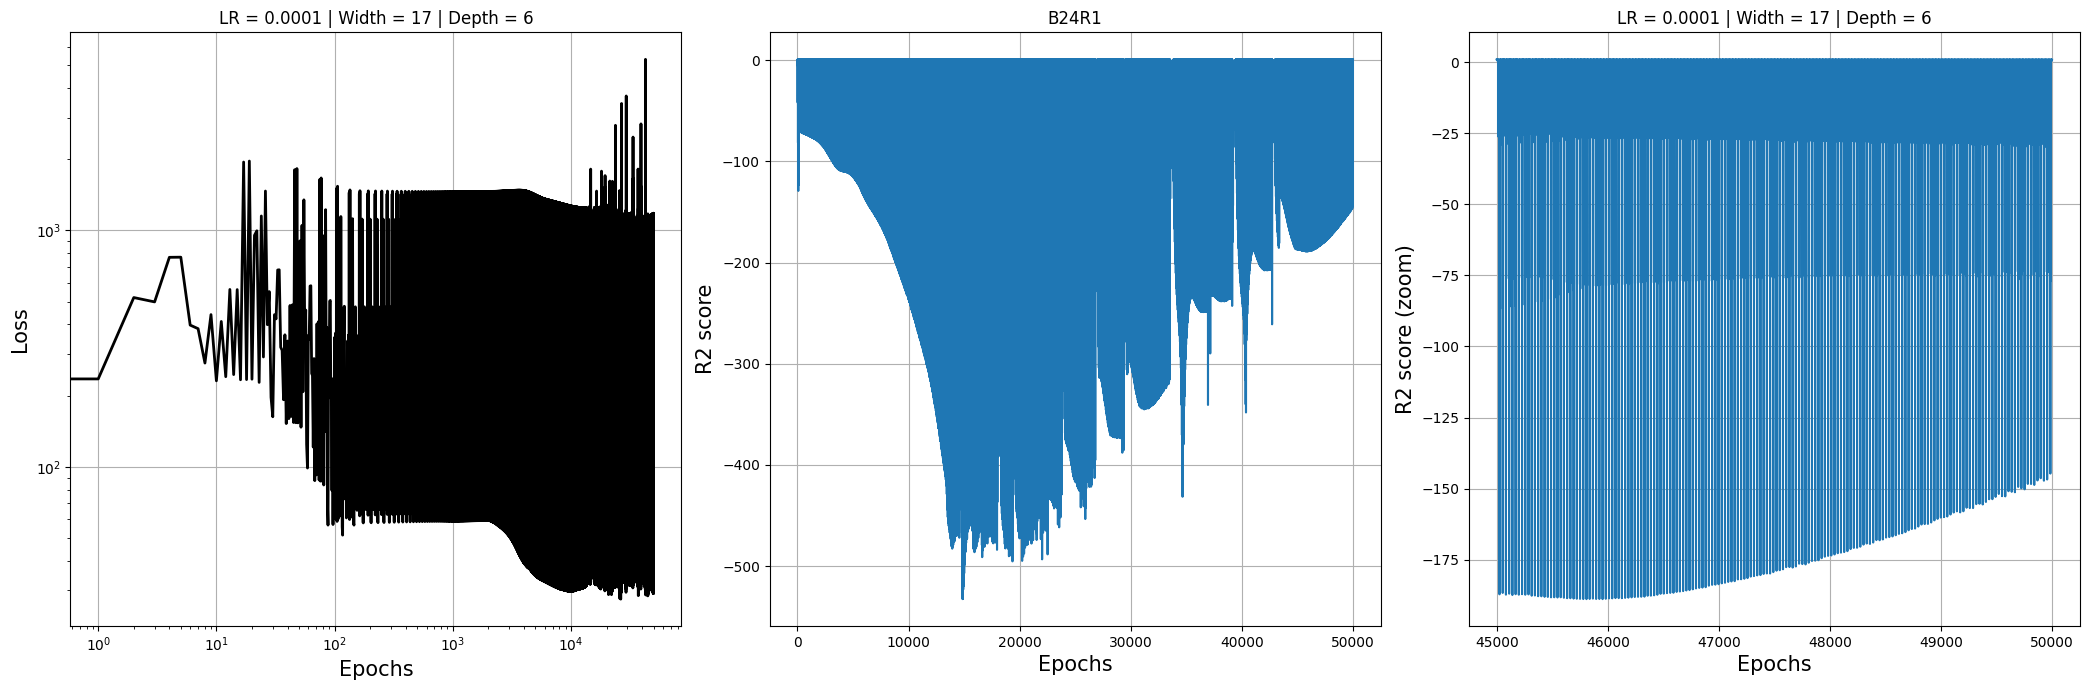

In [46]:
fig, axs = plt.subplots(1, 3, figsize=(21, 7))

axs[0].plot(loss, color='black', linewidth=2)
axs[0].grid(True)
axs[0].set_title(f"LR = {lr} | Width = {width_size} | Depth = {depth}")
axs[0].set_xlabel('Epochs', fontsize=15)
axs[0].set_ylabel('Loss', fontsize=15)
axs[0].set_xscale('log')
axs[0].set_yscale('log')

start_r = int(n_epochs * 0.9)  # zoom into the last 20% of training
t_r = np.arange(start_r, n_epochs, 1)

axs[1].plot(R[0])
axs[1].grid(True)
axs[1].set_title(list(trajectory_store)[bior_test])
axs[1].set_xlabel('Epochs', fontsize=15)
axs[1].set_ylabel('R2 score', fontsize=15)

axs[2].plot(t_r, R[0][start_r:])
axs[2].grid(True)
axs[2].set_title(f"LR = {lr} | Width = {width_size} | Depth = {depth}")
axs[2].set_xlabel('Epochs', fontsize=15)
axs[2].set_ylabel('R2 score (zoom)', fontsize=15)

plt.tight_layout()
plt.show()

In [47]:
# Get the 4 variables for this bioreactor
glc_ys  = trajectory_store[list(trajectory_store)[bior_test]]['Glucose'][1]
od_ys   = trajectory_store[list(trajectory_store)[bior_test]]['DO'][1]
ph_ys   = trajectory_store[list(trajectory_store)[bior_test]]['pH'][1]
bio_ys  = trajectory_store[list(trajectory_store)[bior_test]]['Biomass'][1]
vol_ys = trajectory_store[list(trajectory_store)[bior_test]]['Volume'][1]

# Get the corresponding time arrays
glc_ts  = trajectory_store[list(trajectory_store)[bior_test]]['Glucose'][0]
od_ts   = trajectory_store[list(trajectory_store)[bior_test]]['DO'][0]
ph_ts   = trajectory_store[list(trajectory_store)[bior_test]]['pH'][0]
bio_ts  = trajectory_store[list(trajectory_store)[bior_test]]['Biomass'][0]
vol_ts = trajectory_store[list(trajectory_store)[bior_test]]['Volume'][0]

# Use OD timestamps as the common time grid
t_test = jnp.asarray(od_ts, dtype=jnp.float32)

# Interpolate all variables onto the OD time grid
ys_test = jnp.stack([
    jnp.interp(t_test, jnp.asarray(glc_ts), jnp.asarray(glc_ys)),  # glucose
    jnp.asarray(od_ys,  dtype=jnp.float32),                    # OD (reference)
    jnp.interp(t_test, jnp.asarray(ph_ts),  jnp.asarray(ph_ys)),   # pH
    jnp.interp(t_test, jnp.asarray(bio_ts), jnp.asarray(bio_ys)),  # biomass
    jnp.interp(t_test, jnp.asarray(vol_ts), jnp.asarray(vol_ys)),
], axis=1)  # shape (T, 5)

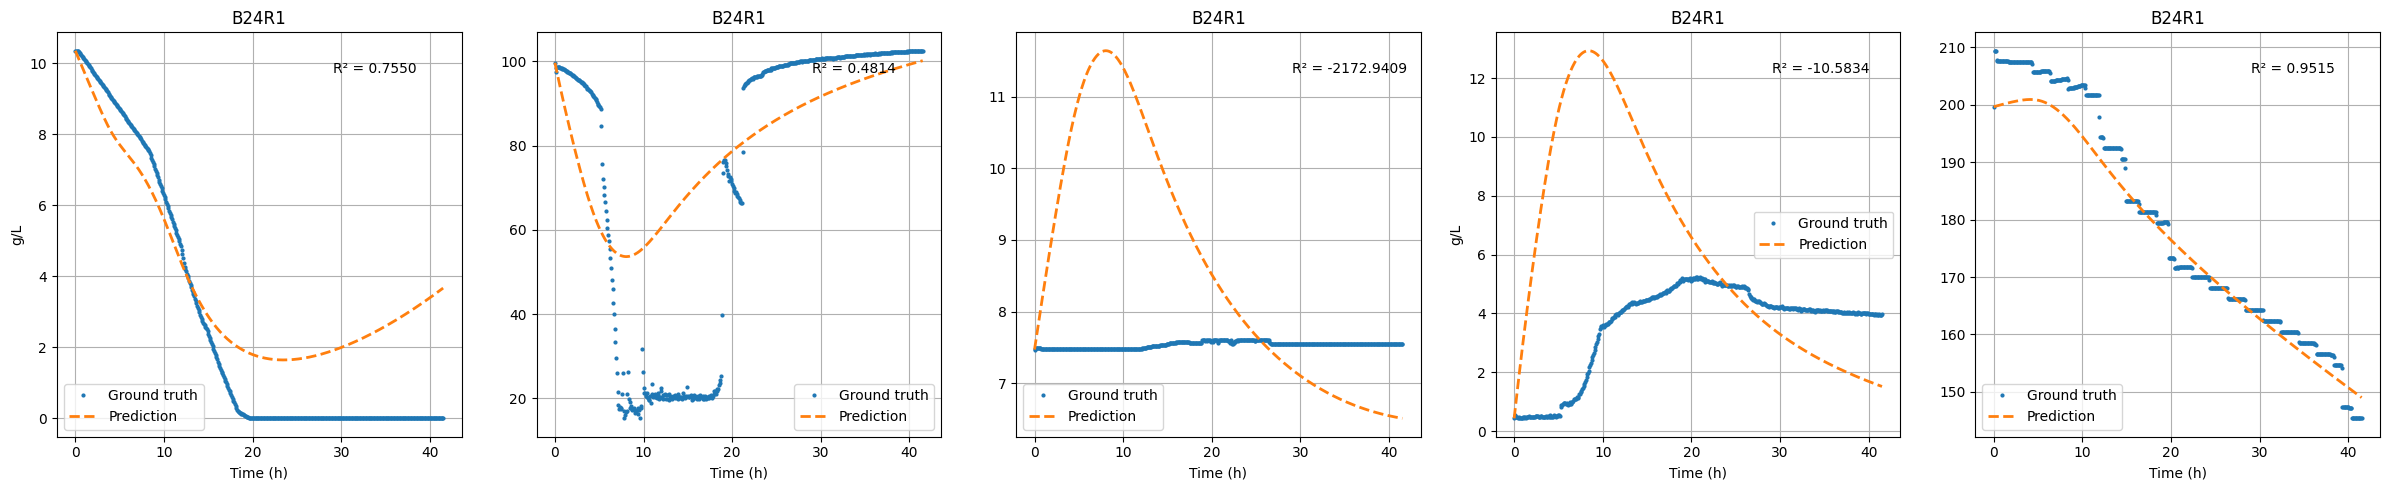

In [48]:
# --- Run the model from the first time point ---
y_pred_test = model(t_test, ys_test[0])  # shape (T, 4)

# --- Compute R2 for each variable ---
y_true_test = torch.tensor(np.asarray(ys_test), dtype=torch.float32)
y_pred_test_torch = torch.tensor(np.asarray(y_pred_test), dtype=torch.float32)

var_names = ["Glucose", "DO", "pH", "Biomass", "Volume"]
units = ["g/L", "", "", "g/L", ""]
# --- Plot predictions vs ground truth ---
fig, axs = plt.subplots(1, 5, figsize=(24, 5))
for var_idx, name in enumerate(var_names):
    ss_res = torch.sum((y_true_test[:, var_idx] - y_pred_test_torch[:, var_idx]) ** 2)
    ss_tot = torch.sum((y_true_test[:, var_idx] - torch.mean(y_true_test[:, var_idx])) ** 2)
    r2 = 1 - ss_res / (ss_tot + 1e-12)
    y_r2 = (y_pred_test[:, ][var_idx][1]+y_pred_test[:, ][var_idx][-1])/2
    axs[var_idx].plot(t_test, ys_test[:, var_idx], "o",label="Ground truth", linewidth=2, markersize=2)
    axs[var_idx].plot(t_test, y_pred_test[:, var_idx], label="Prediction", linewidth=2, linestyle="--")
    axs[var_idx].set_title(list(trajectory_store)[bior_test])
    axs[var_idx].set_xlabel("Time (h)")
    axs[var_idx].set_ylabel(units[var_idx])
    axs[var_idx].legend()
    ymin, ymax = axs[var_idx].get_ylim()

    axs[var_idx].text(
        t_test[-1] * 0.7,
        ymin + 0.9 * (ymax - ymin),
        f"R² = {r2:.4f}"
    )
    axs[var_idx].grid(True)

plt.tight_layout()
plt.show()
